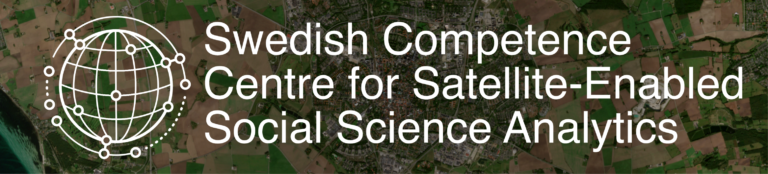

# **Workshop Overview**

This notebook assesses how an extreme flood in **Karlstad, Sweden** affects buildings, roads, critical infrastructure and the population's access to key public services. It is organised in three parts:

- **Environment Set Up [A]**: install libraries and download all workshop datasets.
- **A: Basic Analysis** *(covered live)*: OSM data, critical infrastructure, MSB flood hazard (100-year scenario), flood zone detection, accessibility analysis, population and land cover exposure.
- **B: Supplemental Analysis** *(self-study)*: comparison of the 50-, 100- and 200-year scenarios, exposure across scenarios and the relationship between severity and likelihood.

Open the **Table of Contents** (≡ icon in the left sidebar) to jump between sections. Run the cells in order from top to bottom.

# **Environment Set Up [A]**

Run the cells of this part once at the start of the session. They install the required Python libraries and download all workshop datasets from the GitHub repository into the Colab runtime.

### **Installation & Import of Required Libraries**

In [ ]:
#! indicates a Linux command
!pip install -q osmnx==2.1.1 geopandas==1.0.1 networkx==3.4.2 rasterio==1.4.3 contextily==1.6.2 shapely==2.1.1 pyproj==3.7.0 matplotlib-scalebar==0.9.0

# Documentation of the installed libraries:
# osmnx               -> https://osmnx.readthedocs.io/
# geopandas           -> https://geopandas.org/
# networkx            -> https://networkx.org/documentation/stable/
# rasterio            -> https://rasterio.readthedocs.io/
# contextily          -> https://contextily.readthedocs.io/
# shapely             -> https://shapely.readthedocs.io/
# pyproj              -> https://pyproj4.github.io/pyproj/stable/
# matplotlib-scalebar -> https://github.com/ppinard/matplotlib-scalebar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 49.2 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
import textwrap
import pandas as pd
import numpy as np
import os
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.windows import from_bounds
import contextily as ctx
from shapely.ops import unary_union
from rasterio.features import shapes
from shapely.geometry import shape
from shapely.geometry import box
from rasterio.transform import xy
from shapely.geometry import Point
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="osmnx")
ox.settings.use_cache = True
ox.settings.log_console = False

print(f"osmnx {ox.__version__} | geopandas {gpd.__version__} | "
      f"networkx {nx.__version__} | rasterio {rasterio.__version__} | "
      f"shapely {__import__('shapely').__version__}")

osmnx 2.1.1 | geopandas 1.0.1 | networkx 3.4.2 | rasterio 1.4.3 | shapely 2.1.1


### **Download of Required Datasets from GitHub**

In [ ]:
#Download all the required datasets of the workshop from GitHub repository.
BASE_URL = "https://raw.githubusercontent.com/sesac-sweden/riscon26-workshop/main"
FILES = [
    "Karlstad_100_djup.tif", #flood_dataset [return period: 100],(2mx2m)
    "Karlstad_200_djup.tif", #flood_dataset [return period: 200],(2mx2m)
    "Karlstad_50_djup.tif", #flood_dataset [return period: 50],(2mx2m)
    "Karlstad_nmd2018.tif", #land cover dataset (5kmx5km)
    "SCB_population_Karlstad_5km.gpkg", #population dataset (1kmx1km)
    "karlstad_osm.gpkg",        # buildings/roads/water/landuse, pre-fetched
    "karlstad_pois.gpkg",       # hospitals/fire_stations/schools, pre-fetched
    "karlstad_drive.graphml",   # road network, pre-fetched
    ]

for f in FILES:
    !wget -q -N "{BASE_URL}/{f}"
print("Ready to use datasets:)")

Ready to use datasets:)


# **A: Basic Analysis**

Part A is covered live in the workshop. Using the 100-year flood scenario for Karlstad, it moves step by step from the input data (OpenStreetMap, MSB flood hazard, SCB population, NMD land cover) to the flood zone, the exposed critical infrastructure, and the change in travel-time accessibility for the population.

## **Retrieval & Exploration of OSM Data**

OpenStreetMap (OSM) is a collaborative, open geographic database containing a wide range of spatial features, including roads, buildings, land use, waterways, points of interest, and other infrastructure. Because the data are continuously updated by a global community of contributors, OSM provides a flexible and detailed source of geospatial information for local-scale analyses.
For Sweden, regional OSM data extracts are available through the *Geofabrik download service (https://download.geofabrik.de/europe/sweden.html)*. The Swedish extract is provided in several formats, including the (.osm), (.pbf) format for raw OSM data and GeoPackage or Shapefile formats for direct use in GIS software.

The file downloads automatically as
***"karlstad_osm.gpkg"*** together with the other datasets (see Environment Set Up).

### **Basic Exploration of OSM Dataset**

OSM DATASET OVERVIEW

Total number of OSM features: 59,001

Dataset dimensions: (59001, 8)

Available attributes:
  -> element
  -> id
  -> building
  -> highway
  -> waterway
  -> natural
  -> landuse
  -> geometry

Geometry types:
Polygon            34401
LineString         20273
Point               3846
MultiLineString      336
MultiPolygon         145
Name: count, dtype: int64
Buildings: 28933
Roads: 23913
Water: 852
Landuse: 5305


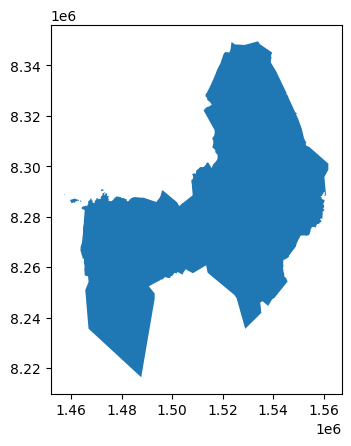

In [ ]:
# 1. Boundary
gdf_boundary = gpd.read_file("karlstad_osm.gpkg", layer="boundary")

# 2. Reproject
gdf_proj = gdf_boundary.to_crs(epsg=3857)

# 3. Quick plot of the boundary
gdf_proj.plot()

# 4. Download OSM features inside boundary
tags = {
    "building": True,
    "highway": True,
    "waterway": True,
    "natural": ["water"],
    "landuse": True }

osm_data = gpd.read_file("karlstad_osm.gpkg", layer="features")

# 5. Reproject (keep the same as the boundary)
osm_proj = osm_data.to_crs(epsg=3857)

# 6. Basic OSM Dataset Exploration

print("OSM DATASET OVERVIEW")

print(f"\nTotal number of OSM features: {len(osm_proj):,}") #summurizing features

print(f"\nDataset dimensions: {osm_proj.shape}")

print("\nAvailable attributes:") #summurizing attributes
for col in osm_proj.columns:
    print(f"  -> {col}")

print("\nGeometry types:") #summurizing geometries
print(osm_proj.geometry.geom_type.value_counts())

# 7. Split into layers safely
buildings = osm_proj[osm_proj["building"].notna()] if "building" in osm_proj.columns else None
print("Buildings:", len(buildings) if buildings is not None else 0)

roads = osm_proj[osm_proj["highway"].notna()] if "highway" in osm_proj.columns else None
print("Roads:", len(roads) if roads is not None else 0)

water = osm_proj[
    osm_proj["waterway"].notna() |
    (osm_proj.get("natural", "").astype(str) == "water")
] if "waterway" in osm_proj.columns or "natural" in osm_proj.columns else None
print("Water:", len(water) if water is not None else 0)

landuse = osm_proj[osm_proj["landuse"].notna()] if "landuse" in osm_proj.columns else None
print("Landuse:", len(landuse) if landuse is not None else 0)

### **Visualization of OSM Layers in Karlstad Municipality, Sweden**

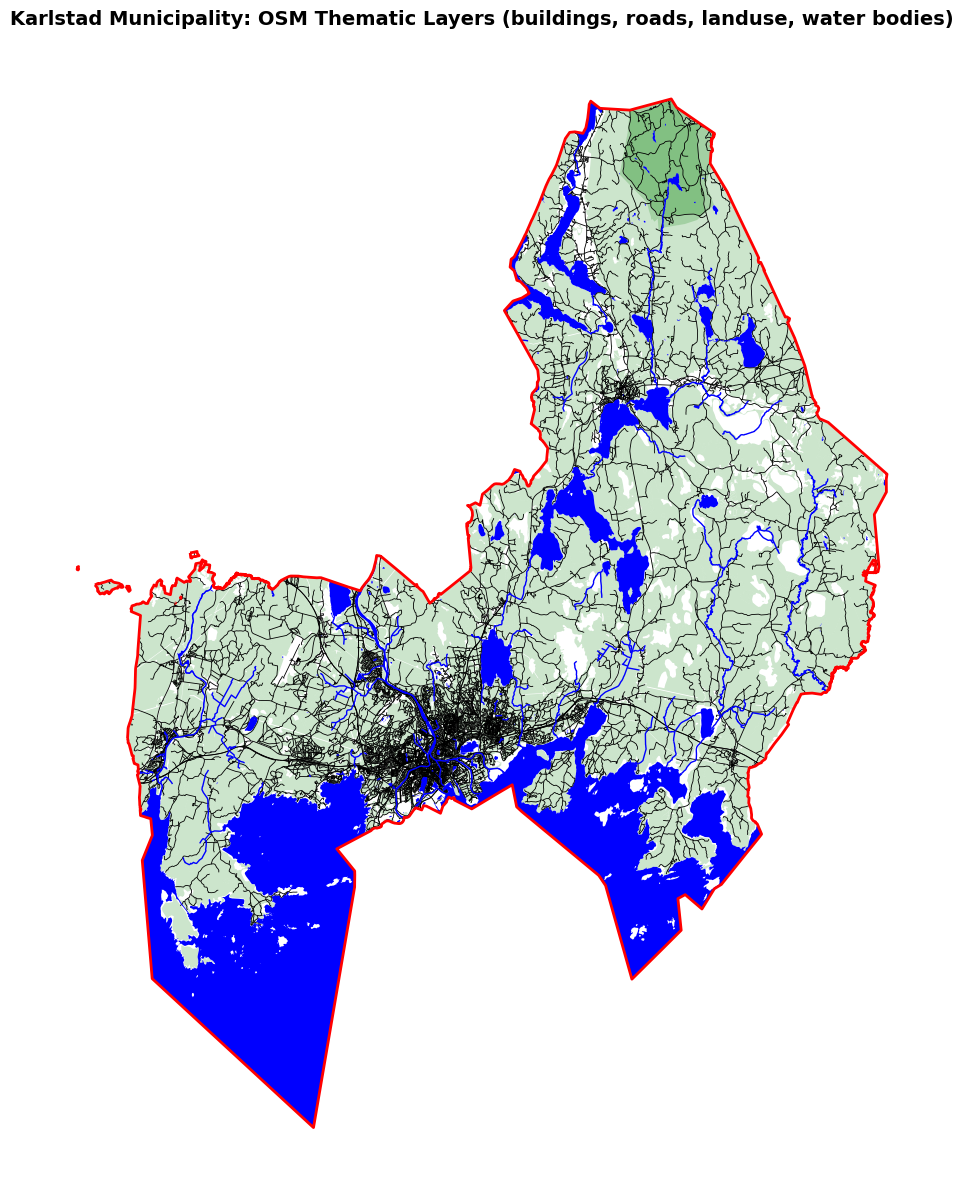

In [ ]:
# 7. Clip to boundary
def clip(layer):
    if layer is None:
        return None
    return gpd.clip(layer, gdf_proj)

buildings = clip(buildings)
roads = clip(roads)
water = clip(water)
landuse = clip(landuse)

# 8. Remove points for now (keep only lines/polygons for clean map)
#Definition of the function (remove_points)
def remove_points(layer):
    if layer is None:
        return None
    return layer[layer.geometry.type.isin(["Polygon", "MultiPolygon", "LineString", "MultiLineString"])]

buildings = remove_points(buildings) #call the function
roads = remove_points(roads)
water = remove_points(water)
landuse = remove_points(landuse)

# 9. PLOTTING TIME
fig1, ax = plt.subplots(figsize=(12, 12))

if landuse is not None and not landuse.empty:
    landuse.plot(ax=ax, color="green", alpha=0.2)

if buildings is not None and not buildings.empty:
    buildings.plot(ax=ax, color="lightgrey", alpha=0.7)

if roads is not None and not roads.empty:
    roads.plot(ax=ax, color="black", linewidth=0.6)

if water is not None and not water.empty:
    water.plot(ax=ax, color="blue", linewidth=1.0)

gdf_proj.boundary.plot(ax=ax, color="red", linewidth=2)

ax.set_title(
    "Karlstad Municipality: OSM Thematic Layers (buildings, roads, landuse, water bodies)",
    fontsize=14,
    fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.close(fig1)

Buildings (polygons): 28,931
Total building footprint: 6.40 km²
Total mapped road length: 4,360 km


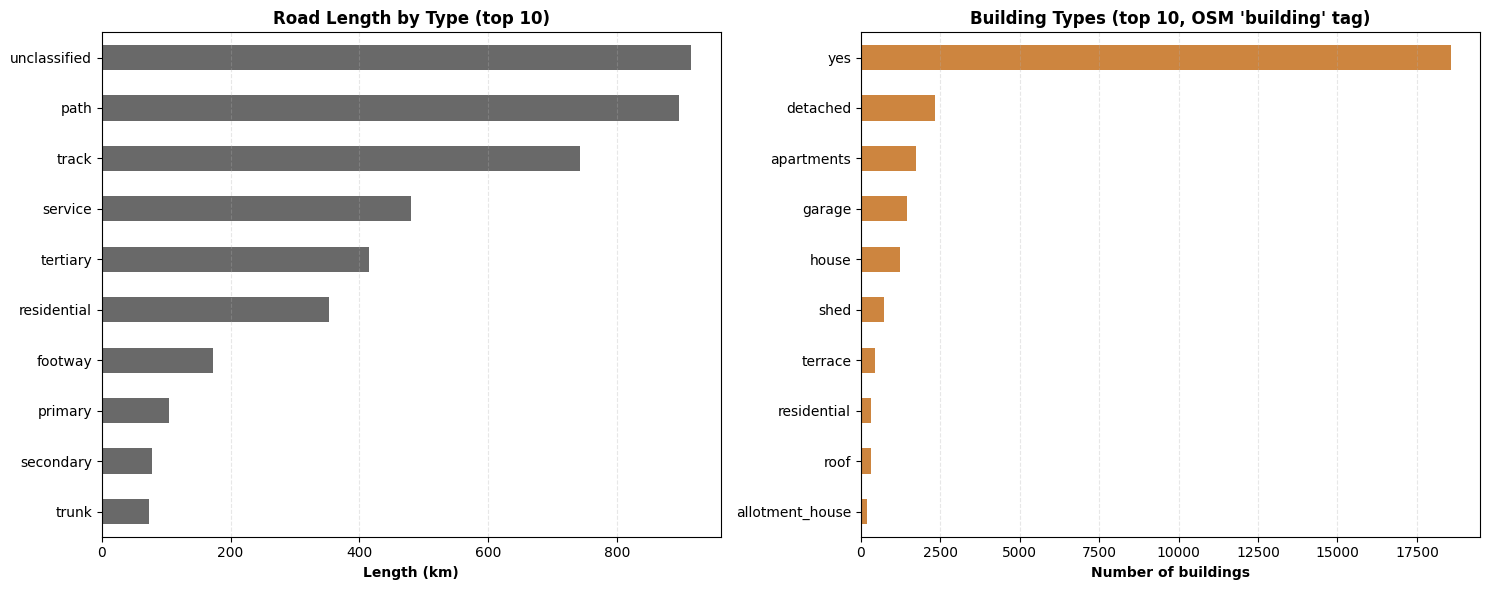

In [ ]:
utm = gdf_proj.estimate_utm_crs()

roads_m = roads.to_crs(utm)
roads_m = roads_m[roads_m.geometry.type.isin(["LineString", "MultiLineString"])].copy()
roads_m["hw"] = roads_m["highway"].astype(str)
roads_m["km"] = roads_m.geometry.length / 1000
road_km = roads_m.groupby("hw")["km"].sum().sort_values(ascending=False)

buildings_m = buildings.to_crs(utm)
buildings_m = buildings_m[buildings_m.geometry.type.isin(["Polygon", "MultiPolygon"])]
bld_types = buildings_m["building"].astype(str).value_counts()

print(f"Buildings (polygons): {len(buildings_m):,}")
print(f"Total building footprint: {buildings_m.geometry.area.sum() / 1e6:.2f} km²")
print(f"Total mapped road length: {road_km.sum():,.0f} km")

fig1a, axes = plt.subplots(1, 2, figsize=(15, 6))
road_km.head(10).sort_values().plot.barh(ax=axes[0], color="dimgrey")
axes[0].set_xlabel("Length (km)", fontweight="bold")
axes[0].set_ylabel("")
axes[0].set_title("Road Length by Type (top 10)", fontweight="bold")

bld_types.head(10).sort_values().plot.barh(ax=axes[1], color="peru")
axes[1].set_xlabel("Number of buildings", fontweight="bold")
axes[1].set_ylabel("")
axes[1].set_title("Building Types (top 10, OSM 'building' tag)", fontweight="bold")

for a in axes:
    a.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig1a)

## **Critical Infrastructure Detection from OSM Datasets**

**Point of Interest (POI) data** extracted from OSM dataset to study the distribution of key public services in the city. POIs represent specific geographic locations such as **schools, hospitals, and fire stations**, which are identified through their attribute tags in the dataset.

The file downloads automatically as
***"karlstad_pois.gpkg"*** together with the other datasets (see Environment Set Up).

**Data-quality note:** OSM detects only 1 hospital and 3 fire stations in the
municipality. Any statistic built on these categories rests on very few data
points and should be read with that in mind — OSM completeness varies by
region and is not guaranteed.

In [ ]:
# 1. Load Points of Interest (POI) layers from the pre-fetched GeoPackage
# (hospitals, fire stations, schools -- see Environment Set Up)
hospitals_all = gpd.read_file("karlstad_pois.gpkg", layer="hospitals")
fire_stations_all = gpd.read_file("karlstad_pois.gpkg", layer="fire_stations")
schools_all = gpd.read_file("karlstad_pois.gpkg", layer="schools")

# 2. Final summary (totals)
print("FINAL TOTALS")
print("Hospitals:", len(hospitals_all))
print("Fire stations:", len(fire_stations_all))
print("Schools:", len(schools_all))
print("\nTotal POIs:", len(hospitals_all) + len(fire_stations_all) + len(schools_all))

# 3. Combine into a single GeoDataFrame for quick inspection
pois = pd.concat([hospitals_all, fire_stations_all, schools_all], ignore_index=True)
print("\nUnique amenities found:", pois["amenity"].unique())
pois_points = pois[pois.geometry.type == "Point"].copy()

FINAL TOTALS
Hospitals: 1
Fire stations: 3
Schools: 53

Total POIs: 57

Unique amenities found: ['hospital' 'fire_station' 'school']


### **Spatial Distribution of Critical Infrastructure**

NameError: name 'ScaleBar' is not defined

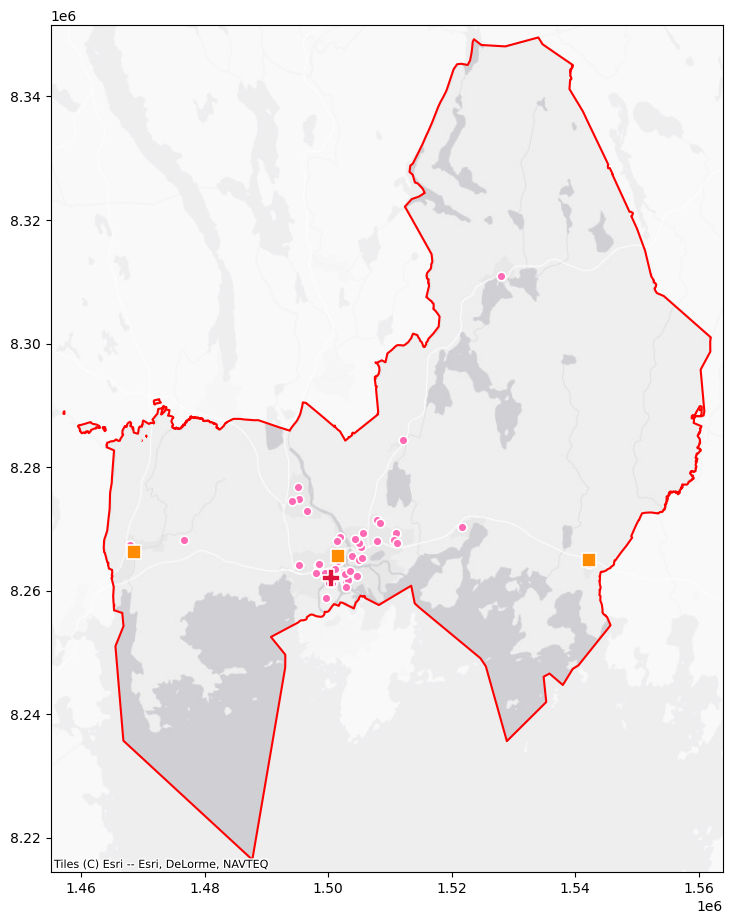

In [ ]:
# 7. Project everything to Web Mercator (needed for the basemap)
boundary_web = gdf_boundary.to_crs(epsg=3857)

def to_points(gdf):
    """Copy of the layer as points (we don't modify the original POI datasets)."""
    pts = gdf.to_crs(epsg=3857).copy()
    pts["geometry"] = pts.geometry.representative_point()
    return pts

hospitals_pts = to_points(hospitals_all)
firestations_pts = to_points(fire_stations_all)
schools_pts = to_points(schools_all)

# 8. Map extent and a white mask that fades everything outside the municipality
xmin, ymin, xmax, ymax = boundary_web.total_bounds
pad = 2000  # metres around the municipality
outside = gpd.GeoDataFrame(
    geometry=[box(xmin - 10 * pad, ymin - 10 * pad, xmax + 10 * pad, ymax + 10 * pad)
              .difference(boundary_web.union_all())],
    crs="EPSG:3857")

# 9. PLOTTING TIME
fig2, ax = plt.subplots(figsize=(11, 11))
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas, zorder=0)
outside.plot(ax=ax, color="white", alpha=0.65, zorder=1)
boundary_web.boundary.plot(ax=ax, color="red", linewidth=1.5, zorder=2)

# Facilities (white halo + coloured marker for readability)
for pts, color, marker, size, label in [
    (schools_pts, "hotpink", "o", 40, "Schools"),
    (firestations_pts, "darkorange", "s", 90, "Fire Stations"),
    (hospitals_pts, "crimson", "P", 160, "Hospitals")]:
    pts.plot(ax=ax, color=color, marker=marker, markersize=size,
             edgecolor="white", linewidth=1.2, zorder=3,
             label=f"{label} ({len(pts)})")

# Scale bar (Web Mercator stretches distances, so correct for the latitude)
lat = gdf_boundary.to_crs(epsg=4326).union_all().centroid.y
ax.add_artist(ScaleBar(dx=np.cos(np.radians(lat)), units="m", location="lower left",
                       box_alpha=0.8, font_properties={"size": 10}))

# North arrow
ax.annotate("N", xy=(0.95, 0.13), xytext=(0.95, 0.05), xycoords="axes fraction",
            ha="center", va="center", fontsize=14, fontweight="bold",
            arrowprops=dict(facecolor="black", edgecolor="black", width=4, headwidth=12))

ax.set_title("Spatial Distribution of Critical Facilities in Karlstad Municipality",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(frameon=True, loc="upper right", prop={"size": 11}, title="Facilities",
          title_fontproperties={"weight": "bold"}, framealpha=0.95)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.close(fig2)

## **Flood Datasets from MSB**
Flood hazard data provide spatial information on areas that may be affected by flooding under different scenarios. In Sweden, flood hazard and risk information is provided by the Swedish Civil Contingencies Agency MSB through its Flood Portal (https://gisapp.msb.se/Apps/oversvamningsportal/index.html). These datasets can be used to identify areas exposed to different flood scenarios and to assess their potential impacts on people, infrastructure, and accessibility.

In this step of the workshop, we use a GeoTIFF (.tif) flood hazard dataset ***("Karlstad_100_djup.tif")*** for Karlstad representing an extreme flood scenario with a 100-year return period. The dataset provides information on the spatial distribution and depth of inundation, which will later be combined with other spatial layers to assess accessibility to critical infrastructure under flood conditions.

### **Basic Dataset Exploration using Water Depth Values (m)**

In [ ]:
# 1. Open the retrieved dataset of water depth
with rasterio.open("Karlstad_100_djup.tif") as src:
    print(src.tags())
    data = src.read(1)
    flood_crs = src.crs
    flood_transform = src.transform
    flood_nodata = src.nodata

print("CRS:", flood_crs)
print("NoData value:", flood_nodata)
print("dtype:", data.dtype)

valid_mask = (data != flood_nodata) if flood_nodata is not None else np.isfinite(data)
print("Min (valid only):", np.nanmin(data[valid_mask]))
print("Max (valid only):", np.nanmax(data[valid_mask]))

vals = np.unique(data[valid_mask])
print("Number of unique values:", len(vals))
print("First 20 unique values:", vals[:20])

{'DataType': 'Generic', 'AREA_OR_POINT': 'Area'}
CRS: PROJCS["SWEREF99_Transverse_Mercator",GEOGCS["SWEREF99",DATUM["SWEREF99",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6619"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4619"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
NoData value: -3.4028230607370965e+38
dtype: float32
Min (valid only): 0.01
Max (valid only): 1.57
Number of unique values: 244
First 20 unique values: [0.01       0.01000094 0.01000136 0.01999927 0.01999968 0.0300014
 0.03000182 0.03999972 0.04000014 0.05000186 0.05000228 0.06000018
 0.0600006  0.06999892 0.07000232 0.08000064 0.08000106 0.08999896
 0.08999938 0.1000011 ]


**Key statistics of the water depth and the flooded area per depth class.**


Wet area (depth > 0): 88.32 km²
Mean depth: 1.45 m | Median: 1.57 m | 95th percentile: 1.57 m | Max: 1.57 m
Depth class (m)  Area (km²)  Share (%)
          0-0.1        0.68       0.77
        0.1-0.3        1.39       1.58
        0.3-0.5        1.76       2.00
        0.5-1.0        4.82       5.46
        1.0-2.0       79.67      90.20
          > 2.0        0.00       0.00


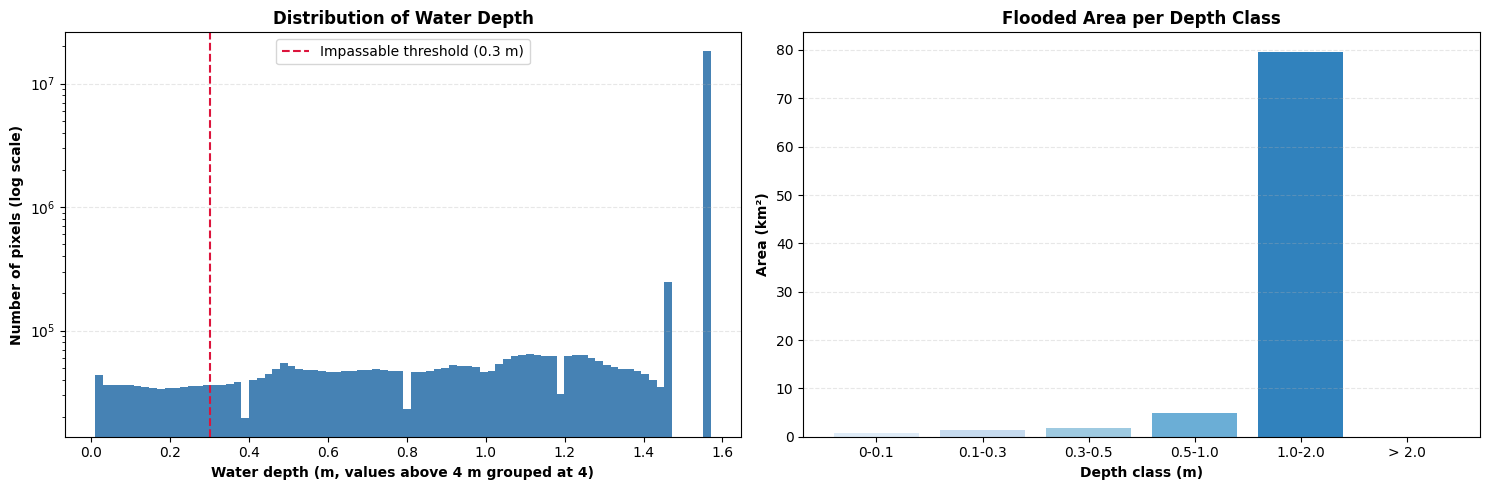

In [ ]:
# 2. Shared flood-detection functions, reused throughout the notebook
# (Section A, Land Cover, Section B) so that every scenario is analysed with
# the same depth threshold and NoData handling
DEPTH_THRESHOLD_M = 0.30  # Pregnolato et al. (2017): max safe depth for driving/steering

#3. Calculating the flooded area based on this threshold
pixel_area_m2 = abs(flood_transform.a * flood_transform.e)
wet = data[valid_mask & (data > 0)].astype(float)

print(f"Wet area (depth > 0): {wet.size * pixel_area_m2 / 1e6:.2f} km²")
print(f"Mean depth: {wet.mean():.2f} m | Median: {np.median(wet):.2f} m | "
      f"95th percentile: {np.percentile(wet, 95):.2f} m | Max: {wet.max():.2f} m")

#4. Spliting in different water depth categories
depth_edges = [0, 0.1, 0.3, 0.5, 1.0, 2.0, np.inf]
depth_names = ["0-0.1", "0.1-0.3", "0.3-0.5", "0.5-1.0", "1.0-2.0", "> 2.0"]
counts, _ = np.histogram(wet, bins=depth_edges)
depth_area_df = pd.DataFrame({"Depth class (m)": depth_names,
                              "Area (km²)": counts * pixel_area_m2 / 1e6})
depth_area_df["Share (%)"] = depth_area_df["Area (km²)"] / depth_area_df["Area (km²)"].sum() * 100
print(depth_area_df.round(2).to_string(index=False))

#5. PLOTTING TIME :)
fig2a, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(np.clip(wet, 0, 4), bins=80, color="steelblue")
axes[0].axvline(DEPTH_THRESHOLD_M, color="crimson", linestyle="--",
                label=f"Impassable threshold ({DEPTH_THRESHOLD_M} m)")
axes[0].set_yscale("log")
axes[0].set_xlabel("Water depth (m, values above 4 m grouped at 4)", fontweight="bold")
axes[0].set_ylabel("Number of pixels (log scale)", fontweight="bold")
axes[0].set_title("Distribution of Water Depth", fontweight="bold")
axes[0].legend()

axes[1].bar(depth_area_df["Depth class (m)"], depth_area_df["Area (km²)"],
            color=["#deebf7", "#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"])
axes[1].set_xlabel("Depth class (m)", fontweight="bold")
axes[1].set_ylabel("Area (km²)", fontweight="bold")
axes[1].set_title("Flooded Area per Depth Class", fontweight="bold")

for a in axes:
    a.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig2a)

## **Detection of Flood Prone Zone in Karlstad**

The water-depth raster is converted into a flood zone by applying a depth threshold and handling NoData values. The detection functions defined here are reused throughout the notebook (Section A, Land Cover and Section B), so that every scenario is analysed in the same way. The critical infrastructure located inside the flood zone is then identified and mapped.

In [ ]:
def get_flood_mask(raster_path, depth_threshold_m=DEPTH_THRESHOLD_M):
    """Reads a flood-depth raster and returns a boolean mask of impassable pixels
    (depth >= depth_threshold_m), excluding NoData values."""
    with rasterio.open(raster_path) as src:
        depth = src.read(1)          # water depth per pixel (m)
        transform = src.transform    # links pixel positions to map coordinates
        crs = src.crs                # coordinate reference system of the raster
        nodata = src.nodata          # value used for "no data" pixels
    # Pixels that hold a real measurement (not NoData)
    valid = (depth != nodata) if nodata is not None else np.isfinite(depth)
    # True where the water is deep enough to count as flooded
    mask = (depth >= depth_threshold_m) & valid
    return mask, depth, transform, crs, valid

def get_flood_polygon(raster_path, depth_threshold_m=DEPTH_THRESHOLD_M):
    """Vectorizes the flooded pixels of a raster into a single dissolved polygon
    (the TRUE flood extent, not a bounding box)."""
    mask, depth, transform, crs, valid = get_flood_mask(raster_path, depth_threshold_m)
    # Convert groups of flooded pixels (raster) into polygons (vector)
    polygons = [
        shape(geom)
        for geom, val in shapes(mask.astype(np.uint8), mask=mask, transform=transform)
        if val == 1
    ]
    # Merge all small polygons into one flood zone (slowest step of the cell)
    flood_geom = unary_union(polygons) if polygons else None
    # Store the flood zone as a GeoDataFrame, in the same CRS as the raster
    gdf = gpd.GeoDataFrame(geometry=[flood_geom] if flood_geom else [], crs=crs)
    return gdf, mask, depth, transform, crs

# 3. Build the flood zone for the reference 100-year scenario
# The function returns five objects; we keep the polygon (flood_zone)
# and the True/False mask (flood), and ignore the rest with "_"
flood_zone, flood, _, _, _ = get_flood_polygon("Karlstad_100_djup.tif")

# Note: "flood zone" here means depth >= 0.30 m, not every wet pixel
print(f"Flood prone zone extracted: depth >= {DEPTH_THRESHOLD_M} m")
print("CRS:", flood_zone.crs)

Flood prone zone extracted: depth >= 0.3 m
CRS: PROJCS["SWEREF99_Transverse_Mercator",GEOGCS["SWEREF99",DATUM["SWEREF99",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6619"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4619"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


Buildings in flood zone: 217 (0.8%)
Roads: 572 | Hospitals: 1 | Fire stations: 0 | Schools: 2


/usr/local/lib/python3.13/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/usr/local/lib/python3.13/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/usr/local/lib/python3.13/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/usr/local/lib/python3.13/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


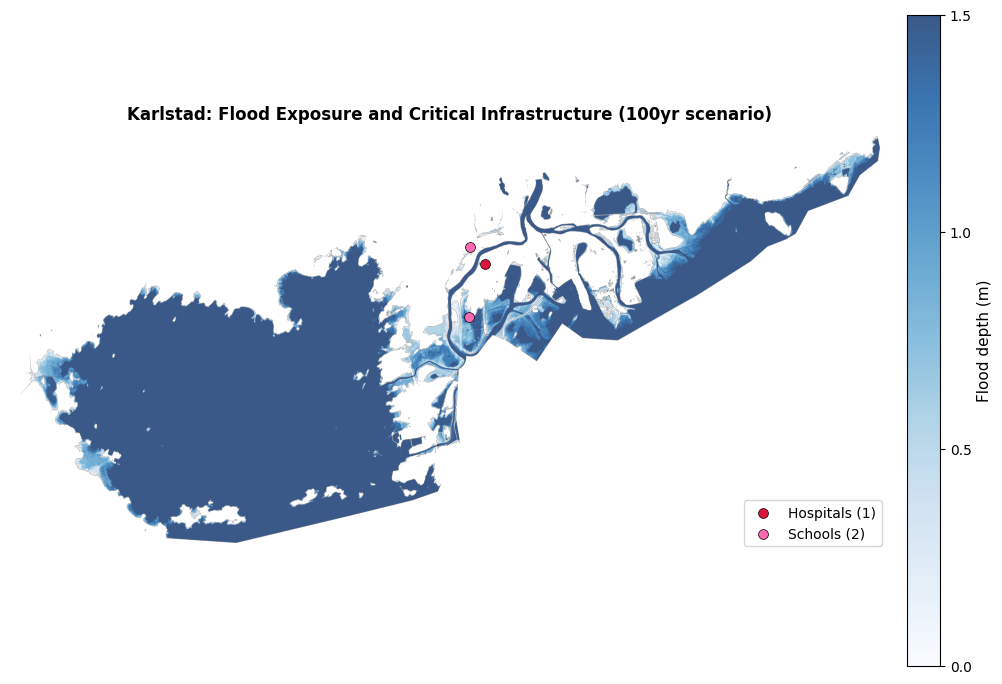

In [ ]:
# 3. Ensure same CRS as the flood raster
zone_geom = flood_zone.geometry.iloc[0]

hospitals_flood = hospitals_all.to_crs(flood_zone.crs)
firestations_flood = fire_stations_all.to_crs(flood_zone.crs)
schools_flood = schools_all.to_crs(flood_zone.crs)
roads = roads.to_crs(flood_zone.crs)
buildings_fz = buildings.to_crs(flood_zone.crs)
buildings_fz = buildings_fz[buildings_fz.geometry.type.isin(["Polygon", "MultiPolygon"])]

# 4. Keep only the features that intersect the detected flood zone
roads_flood = roads.iloc[roads.sindex.query(zone_geom, predicate="intersects")]
buildings_flood = buildings_fz.iloc[buildings_fz.sindex.query(zone_geom, predicate="intersects")].copy()
hospitals_flood = hospitals_flood[hospitals_flood.intersects(zone_geom)]
firestations_flood = firestations_flood[firestations_flood.intersects(zone_geom)]
schools_flood = schools_flood[schools_flood.intersects(zone_geom)]

print(f"Buildings in flood zone: {len(buildings_flood):,} "
      f"({len(buildings_flood) / len(buildings_fz) * 100:.1f}%)")
print(f"Roads: {len(roads_flood):,} | Hospitals: {len(hospitals_flood)} | "
      f"Fire stations: {len(firestations_flood)} | Schools: {len(schools_flood)}")

# 5. PLOTTING TIME
# Plot the water DEPTH (not the True/False mask), hiding NoData and dry pixels
depth_plot = np.ma.masked_where(~valid_mask | (data <= 0), data)

fig3, ax = plt.subplots(figsize=(12, 12))
with rasterio.open("Karlstad_100_djup.tif") as src:
    im = ax.imshow(
        depth_plot,
        extent=[src.bounds.left, src.bounds.right,
                src.bounds.bottom, src.bounds.top],
        cmap="Blues",
        vmin=0,
        vmax=1.5,
        alpha=0.8,
        zorder=1)

# Flooded buildings
buildings_flood.plot(ax=ax, color="dimgrey", alpha=0.6, zorder=2)

# Critical infrastructure (only plotted if present in the flood zone)
for gdf_, color_, label_ in [(hospitals_flood, "crimson", "Hospitals"),
                             (schools_flood, "hotpink", "Schools"),
                             (firestations_flood, "darkorange", "Fire Stations")]:
    if not gdf_.empty:
        gdf_.geometry.centroid.plot(ax=ax, color=color_, markersize=50,
                                    edgecolor="black", linewidth=0.5,
                                    label=f"{label_} ({len(gdf_)})", zorder=3)

# Zoom to the flood zone
xmin, ymin, xmax, ymax = flood_zone.total_bounds
buffer = 300
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

# Colorbar
cbar = fig3.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Flood depth (m)", fontsize=11)
cbar.set_ticks([0, 0.5, 1, 1.5])
cbar.ax.tick_params(labelsize=10)

ax.set_axis_off()
ax.set_title("Karlstad: Flood Exposure and Critical Infrastructure (100yr scenario)",
             fontweight="bold")
ax.legend(loc="lower right", frameon=True)
plt.show()
plt.close(fig3)

## **Accessibility Analysis**

The road network is combined with the flood depth to classify each road segment as **open**, **reduced speed** (water depth 0.10–0.30 m, travelled at half speed) or **impassable** (water depth ≥ 0.30 m, removed from the network). Travel-time isochrones (5, 10 and 15 minutes) around the critical infrastructure are then computed for normal and flood conditions, to show how the area reachable from each facility shrinks during the flood.

In [ ]:
# 1. Road network from pre-fetched GraphML
G = ox.load_graphml("karlstad_drive.graphml")

print(f"Nodes: {len(G.nodes):,}")
print(f"Edges: {len(G.edges):,}")

# 2. Speed & travel times
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# 3. Convert to GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
edges_gdf = edges_gdf.to_crs(flood_zone.crs)

# 4. Zone of depth: 0.10-0.30m
#Driving is slower when water depth < 0.30m
REDUCED_SPEED_THRESHOLD_M = 0.10

reduced_mask_raw = (data >= REDUCED_SPEED_THRESHOLD_M) & (data < DEPTH_THRESHOLD_M) & valid_mask
reduced_polygons = [
    shape(geom)
    for geom, val in shapes(reduced_mask_raw.astype(np.uint8), mask=reduced_mask_raw, transform=flood_transform)
    if val == 1
]
reduced_zone = (
    gpd.GeoDataFrame(geometry=[unary_union(reduced_polygons)], crs=flood_crs)
    if reduced_polygons else None
)

# 5. Road classification: i) impassable (≥0.30m) / ii) reduced (0.10-0.30m) &
# iii)open
impassable_mask = edges_gdf.intersects(flood_zone.geometry.iloc[0])
if reduced_zone is not None:
    reduced_mask = edges_gdf.intersects(reduced_zone.to_crs(edges_gdf.crs).geometry.iloc[0]) & ~impassable_mask
else:
    reduced_mask = pd.Series(False, index=edges_gdf.index)

edges_normal = edges_gdf[~impassable_mask & ~reduced_mask].to_crs(epsg=3857)
edges_reduced = edges_gdf[reduced_mask].to_crs(epsg=3857)
edges_flooded = edges_gdf[impassable_mask].to_crs(epsg=3857)
flood_zone_web = flood_zone.to_crs(epsg=3857)

print("ROADS DATASET OVERVIEW:")
print("Total roads:", len(edges_gdf))
print("Impassable roads (≥0.30m):", impassable_mask.sum())
print("Reduced-speed roads (0.10-0.30m):", reduced_mask.sum())

flooded_mask = impassable_mask

Nodes: 5,146
Edges: 11,910
ROADS DATASET OVERVIEW:
Total roads: 11910
Impassable roads (≥0.30m): 181
Reduced-speed roads (0.10-0.30m): 33


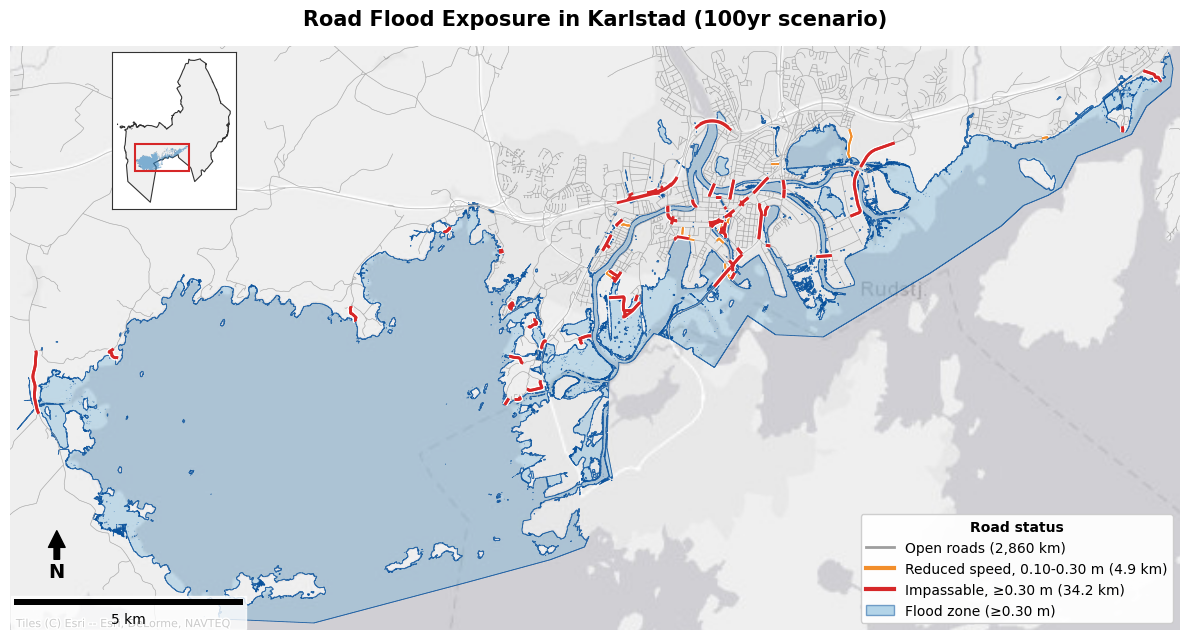

In [ ]:
# Road length per class (two-way streets appear twice in the graph, so remove duplicates)
def road_km(gdf):
    if gdf.empty:
        return 0.0
    d = gdf.reset_index()
    d["a"], d["b"] = np.minimum(d["u"], d["v"]), np.maximum(d["u"], d["v"])
    return d.drop_duplicates(subset=["a", "b", "length"])["length"].sum() / 1000

km_open, km_reduced, km_flooded = road_km(edges_normal), road_km(edges_reduced), road_km(edges_flooded)

# 5. PLOTTING TIME
fig4, ax = plt.subplots(figsize=(12, 12))

# Zoom (extent first, then basemap)
xmin, ymin, xmax, ymax = flood_zone_web.total_bounds
buffer = 300
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas, zorder=0)

# Flood zone: light fill + thin outline
flood_zone_web.plot(ax=ax, color="#6baed6", alpha=0.35, zorder=1)
flood_zone_web.boundary.plot(ax=ax, color="#08519c", linewidth=0.6, alpha=0.8, zorder=1.5)

# Roads
edges_normal.plot(ax=ax, color="#9e9e9e", linewidth=0.4, alpha=0.6, zorder=2)
edges_reduced.plot(ax=ax, color="#f28e2b", linewidth=1.4, zorder=3,
                   path_effects=[pe.Stroke(linewidth=2.8, foreground="white"), pe.Normal()])
edges_flooded.plot(ax=ax, color="#d62728", linewidth=2.0, zorder=4,
                   path_effects=[pe.Stroke(linewidth=3.8, foreground="white"), pe.Normal()])

# Legend with road lengths
legend_elements = [
    Line2D([0], [0], color="#9e9e9e", lw=2, label=f"Open roads ({km_open:,.0f} km)"),
    Line2D([0], [0], color="#f28e2b", lw=3, label=f"Reduced speed, 0.10-0.30 m ({km_reduced:,.1f} km)"),
    Line2D([0], [0], color="#d62728", lw=3, label=f"Impassable, ≥0.30 m ({km_flooded:,.1f} km)"),
    mpatches.Patch(facecolor="#6baed6", alpha=0.5, edgecolor="#08519c", label="Flood zone (≥0.30 m)")]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, frameon=True,
          framealpha=0.95, title="Road status", title_fontproperties={"weight": "bold"})

# Scale bar (corrected for Web Mercator distortion at Karlstad's latitude)
lat = flood_zone_web.to_crs(epsg=4326).union_all().centroid.y
ax.add_artist(ScaleBar(dx=np.cos(np.radians(lat)), units="m", location="lower left",
                       box_alpha=0.8, font_properties={"size": 10}))

# North arrow
ax.annotate("N", xy=(0.04, 0.17), xytext=(0.04, 0.10), xycoords="axes fraction",
            ha="center", va="center", fontsize=14, fontweight="bold",
            arrowprops=dict(facecolor="black", edgecolor="black", width=4, headwidth=12))

# Inset: where the map is located within the municipality
boundary_web = gdf_boundary.to_crs(epsg=3857)
inset = ax.inset_axes([0.01, 0.72, 0.26, 0.27])
boundary_web.plot(ax=inset, color="#f0f0f0", edgecolor="#333333", linewidth=0.8)
flood_zone_web.plot(ax=inset, color="#3182bd", alpha=0.6)
inset.add_patch(mpatches.Rectangle((xmin - buffer, ymin - buffer),
                                   (xmax - xmin) + 2 * buffer, (ymax - ymin) + 2 * buffer,
                                   fill=False, edgecolor="#d62728", linewidth=1.5))
inset.set_xticks([])
inset.set_yticks([])
inset.set_facecolor("white")
for spine in inset.spines.values():
    spine.set_edgecolor("#333333")

# Title
ax.set_title("Road Flood Exposure in Karlstad (100yr scenario)",
             fontsize=15, fontweight="bold", pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.close(fig4)

In [ ]:
# 6. Defining function (compute_isochrones) for travel-time calculation
def compute_isochrones(G, facility_gdf, travel_times_min, label):
    """Returns GeoDataFrame of isochrone polygons"""
    G_proj = ox.project_graph(G)
    nodes_proj, _ = ox.graph_to_gdfs(G_proj)
    fac = facility_gdf.copy()
    fac = fac.to_crs(nodes_proj.crs)
    fac["geometry"] = fac.geometry.centroid

    records = []
    n_failed = 0
    for idx, row in fac.iterrows():
        try:
            nn = ox.nearest_nodes(G_proj, X=row.geometry.x, Y=row.geometry.y)
            for t_min in travel_times_min:
                subG = nx.ego_graph(
                    G_proj, nn,
                    radius=t_min * 60,
                    distance="travel_time")
                sub_nodes, sub_edges = ox.graph_to_gdfs(subG)

                ISOCHRONE_BUFFER_M = 80 #meters buffer around each reachable road segment
                if not sub_edges.empty:
                    hull = sub_edges.geometry.buffer(ISOCHRONE_BUFFER_M).union_all()
                else:
                    hull = sub_nodes.geometry.buffer(ISOCHRONE_BUFFER_M).union_all()
                records.append({
                    "facility": label,
                    "fac_id":   str(idx),
                    "t_min":    t_min,
                    "geometry": hull
                })
        except Exception as e:
            n_failed += 1
            print(f"  ⚠ Failure isochrone for {label} (fac_id={idx}): {type(e).__name__}: {e}")

    if n_failed:
        print(f"  → {n_failed} failures '{label}' (sum {len(fac)} infrastructures × {len(travel_times_min)} times).")

    if not records:
        return None
    return gpd.GeoDataFrame(records, crs=nodes_proj.crs).to_crs(epsg=3857)

In [ ]:
TIMES = [5, 10, 15]

print("Computing isochrones — Normal scenario...")
iso_h_norm = compute_isochrones(G, hospitals_all,     TIMES, "Hospital")
iso_f_norm = compute_isochrones(G, fire_stations_all, TIMES, "Fire Station")
iso_s_norm = compute_isochrones(G, schools_all,       TIMES, "School")

# 7. Construct the flood-affected network:
#    - Segments with water depth 0.10–0.30 m: half speed (reduced_mask), the road remains available
#    - Segments with water depth ≥0.30 m: completely removed (impassable, flooded_mask)
G_flood = G.copy()

for u, v, key in edges_gdf[reduced_mask].index:
    if G_flood.has_edge(u, v, key):
        edge = G_flood[u][v][key]
        old_speed = edge.get("speed_kph", 30)
        edge["speed_kph"] = old_speed * 0.5
        edge["travel_time"] = edge["length"] / (edge["speed_kph"] * 1000 / 3600)

for u, v, key in edges_gdf[flooded_mask].index:
    if G_flood.has_edge(u, v, key):
        G_flood.remove_edge(u, v, key)

print(f"Reduced speed on {reduced_mask.sum()} road segments, removed {flooded_mask.sum()} inaccessible segments.")

print("Computing isochrones — Flood scenario...")
iso_h_flood = compute_isochrones(G_flood, hospitals_all,     TIMES, "Hospital")
iso_f_flood = compute_isochrones(G_flood, fire_stations_all, TIMES, "Fire Station")
iso_s_flood = compute_isochrones(G_flood, schools_all,       TIMES, "School")
print("All isochrones ready :)")

Computing isochrones — Normal scenario...
Reduced speed on 33 road segments, removed 181 inaccessible segments.
Computing isochrones — Flood scenario...
  ⚠ Failure isochrone for School (fac_id=17): ValueError: Graph contains no edges.
  → 1 failures 'School' (sum 53 infrastructures × 3 times).
All isochrones ready :)


/tmp/ipykernel_919/3818789472.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts["geometry"] = pts.geometry.centroid
/tmp/ipykernel_919/3818789472.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts["geometry"] = pts.geometry.centroid


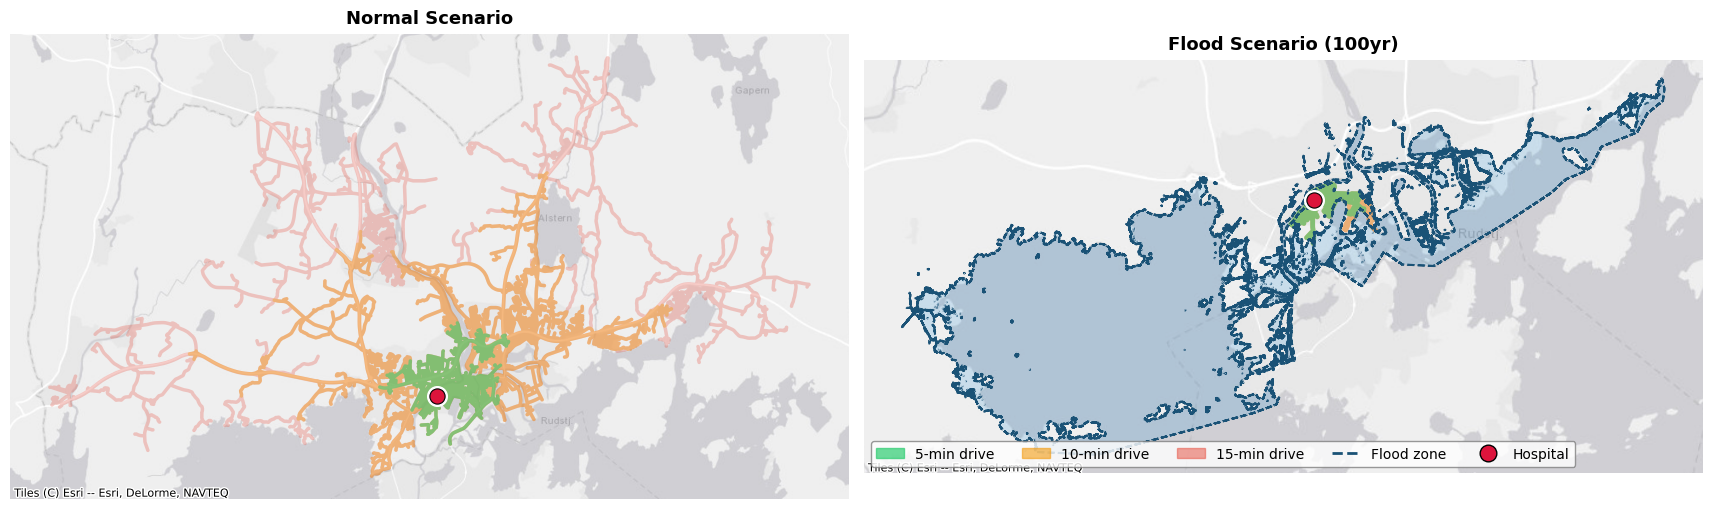

In [ ]:
# 8. PLOTTING TIME
#Creating the color palette for travel-time thresholds
PALETTE = {5: "#2ECC71", 10: "#F39C12", 15: "#E74C3C"}
ALPHA   = {5: 0.55,     10: 0.40,      15: 0.28}

def plot_isochrone_pair(iso_norm, iso_flood, facilities_gdf, #define function
                        fac_color, fac_marker, fac_label, title):
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    for ax, iso, scenario in zip(axes,
                                  [iso_norm, iso_flood],
                                  ["Normal Scenario", "Flood Scenario (100yr)"]):
        if iso is not None:
            for t in reversed(TIMES):
                iso_t = iso[iso["t_min"] == t]
                if not iso_t.empty:
                    iso_t.plot(ax=ax, color=PALETTE[t], alpha=ALPHA[t], zorder=2)
        if scenario != "Normal Scenario":
            flood_zone_web.plot(ax=ax, color="#3498DB", alpha=0.20, zorder=1)
            flood_zone_web.boundary.plot(
                ax=ax, color="#1A5276", linewidth=1.5, linestyle="--", zorder=3)
        pts = facilities_gdf.copy()
        pts["geometry"] = pts.geometry.centroid
        pts = pts.to_crs(epsg=3857)
        pts.plot(ax=ax, color="white", markersize=200, marker=fac_marker, zorder=5)
        pts.plot(ax=ax, color=fac_color, marker=fac_marker,
                 markersize=120, edgecolor="black", linewidth=0.8, zorder=6)
        ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.Esri.WorldGrayCanvas, zorder=0)
        ax.set_title(scenario, fontsize=13, fontweight="bold", pad=8)
        ax.set_axis_off()
    handles = [
        mpatches.Patch(color=PALETTE[5],  alpha=0.7, label="5-min drive"),
        mpatches.Patch(color=PALETTE[10], alpha=0.6, label="10-min drive"),
        mpatches.Patch(color=PALETTE[15], alpha=0.5, label="15-min drive"),
        mlines.Line2D([],[],color="#1A5276", linestyle="--", linewidth=2, label="Flood zone"),
        mlines.Line2D([],[],color=fac_color, marker=fac_marker,
                      linestyle="None", markersize=12, markeredgecolor="black", label=fac_label),]
    axes[1].legend(handles=handles, loc="lower left", fontsize=10, frameon=True,
                   ncol=5, facecolor="white", edgecolor="gray")
    plt.tight_layout()
    return fig

# Plotting for hospital isochrones
fig5 = plot_isochrone_pair(iso_h_norm, iso_h_flood, hospitals_all, "crimson", "o", "Hospital", "Title")
plt.show()
plt.close(fig5)

/tmp/ipykernel_919/3818789472.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts["geometry"] = pts.geometry.centroid
/tmp/ipykernel_919/3818789472.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts["geometry"] = pts.geometry.centroid


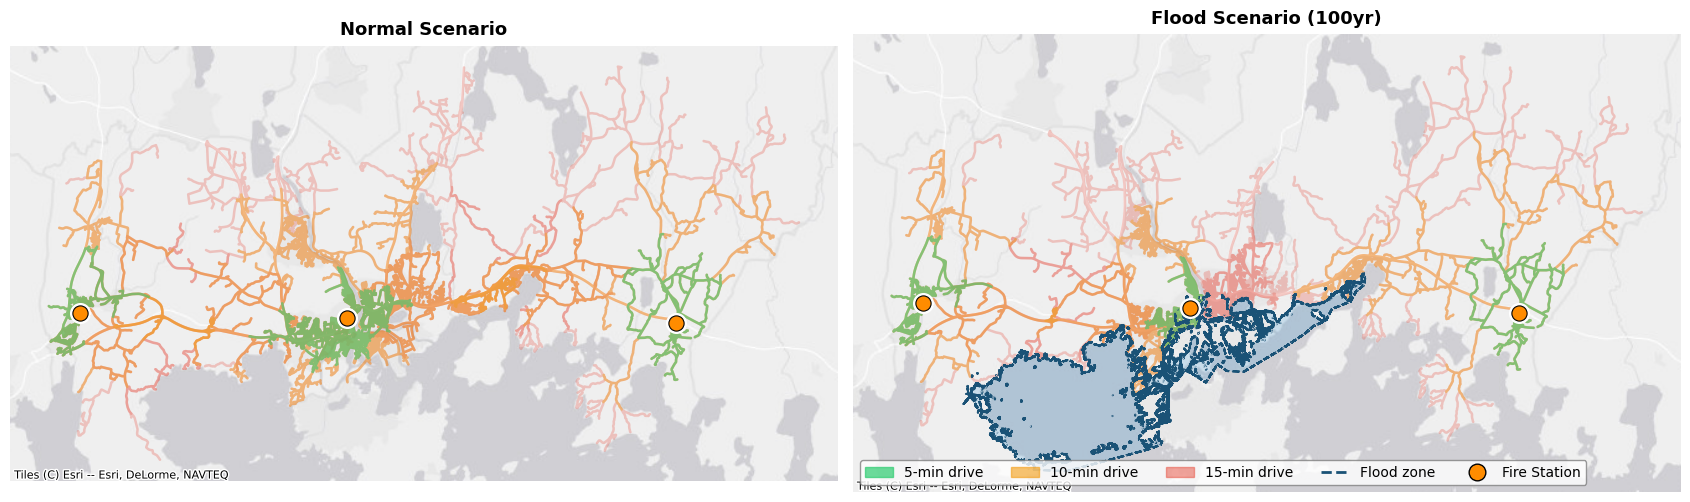

/tmp/ipykernel_919/3818789472.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts["geometry"] = pts.geometry.centroid
/tmp/ipykernel_919/3818789472.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts["geometry"] = pts.geometry.centroid


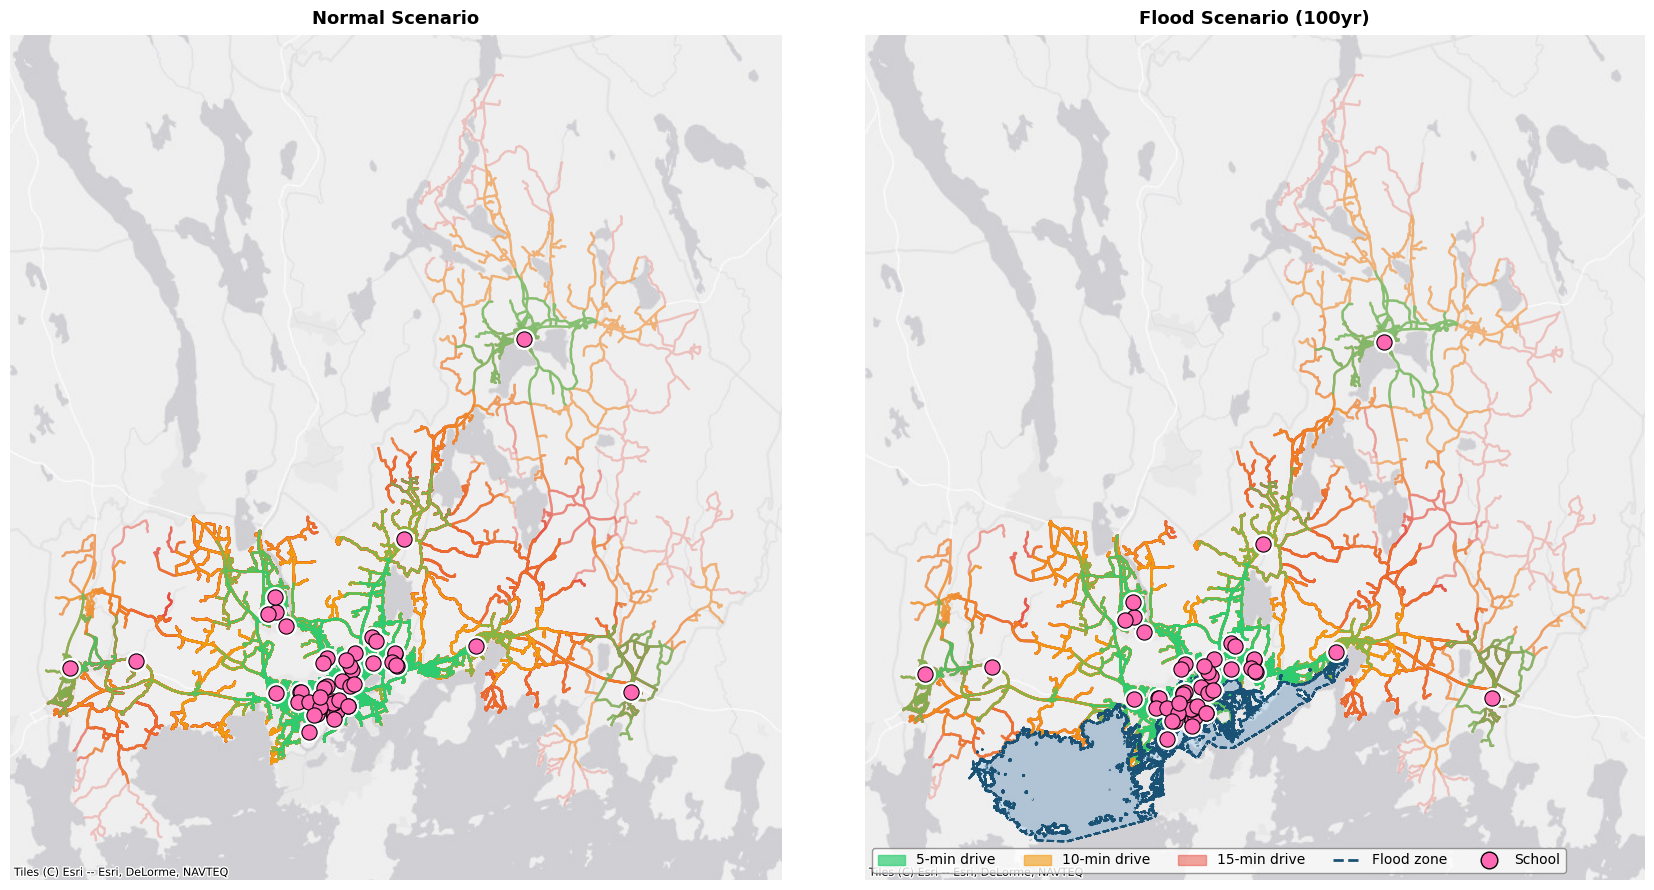

In [ ]:
# Plotting for fire stations isochrones
fig6 = plot_isochrone_pair(iso_f_norm, iso_f_flood, fire_stations_all, "darkorange", "o", "Fire Station", "Title")
plt.show()
plt.close(fig6)

# Plotting for school isochrones
fig7 = plot_isochrone_pair(iso_s_norm, iso_s_flood, schools_all, "hotpink", "o", "School", "Title")
plt.show()
plt.close(fig7)

## **Population Data from Statistics Sweden (SCB)**

Population data are used to represent the spatial distribution of the population within the study area and to identify how many people may be affected by the flood scenario. For Sweden, **Statistics Sweden (SCB)** (https://www.scb.se/en/finding-statistics/statistics-by-subject-area/population-and-living-conditions/population-composition-and-development/population-statistics/) provides population statistics as open geospatial data, including population counts distributed across **1 km × 1 km grid cells**. The data are derived from the Swedish Total Population Register and are updated annually.

In this workshop, the population grid is used to estimate the number of people located within the flood-affected area and to investigate how changes in accessibility to critical infrastructure may affect the population. The gridded format allows the population data to be spatially combined with the **flood hazard** and **road network** datasets used in the analysis.

The file downloads automatically as
***"SCB_population_Karlstad_5km.gpkg"*** together with the other datasets (see Environment Set Up).

In [ ]:
# 1. Load SCB population grid and align CRS with the isochrones (EPSG:3857)
pop_gdf = gpd.read_file("SCB_population_Karlstad_5km.gpkg").to_crs(epsg=3857)

pop_col = "beftotalt"  # Total population per 1 km x 1 km grid cell (SCB)

# 2. Build broad age groups from the SCB 5-year age classes
age_groups = {
    "Children and youth (0-19)": ["ald0_4", "ald5_9", "ald10_14", "ald15_19"],
    "Working age (20-64)":       ["ald20_24", "ald25_29", "ald30_34", "ald35_39", "ald40_44",
                                  "ald45_49", "ald50_54", "ald55_59", "ald60_64"],
    "Older adults (65-79)":      ["ald65_69", "ald70_74", "ald75_79"],
    "Aged 80+":                  ["ald80_84", "ald85_89", "ald90_94", "ald95_99", "ald100w"],
}

# Two groups we follow in the analysis:
# - aged 80+: less mobile, more dependent on hospital and emergency services
# - school age (5-19): the actual users of schools
pop_gdf["elderly_80plus"] = pop_gdf[age_groups["Aged 80+"]].sum(axis=1)
pop_gdf["school_age"] = pop_gdf[["ald5_9", "ald10_14", "ald15_19"]].sum(axis=1)

# 3. Basic exploration
total_pop = pop_gdf[pop_col].sum()
populated = pop_gdf[pop_gdf[pop_col] > 0]

print("SCB POPULATION GRID OVERVIEW")
print(f"\nGrid cells: {len(pop_gdf):,} (of which populated: {len(populated):,})")
print(f"Total population in the grid: {total_pop:,.0f}")
print(f"Most populated cell: {pop_gdf[pop_col].max():,.0f} people per km²")
print(f"Median populated cell: {populated[pop_col].median():,.0f} people per km²")

age_summary = pd.DataFrame({
    "Population": {name: int(pop_gdf[cols].sum().sum()) for name, cols in age_groups.items()}})
age_summary["Share (%)"] = (age_summary["Population"] / total_pop * 100).round(1)
print("\nAge structure:")
print(age_summary.to_string())
print(f"\nSchool age (5-19): {pop_gdf['school_age'].sum():,.0f} "
      f"({pop_gdf['school_age'].sum() / total_pop * 100:.1f}%)")

SCB POPULATION GRID OVERVIEW

Grid cells: 1,270 (of which populated: 1,154)
Total population in the grid: 140,962
Most populated cell: 6,894 people per km²
Median populated cell: 11 people per km²

Age structure:
                           Population  Share (%)
Children and youth (0-19)       30889       21.9
Working age (20-64)             79134       56.1
Older adults (65-79)            21100       15.0
Aged 80+                         9577        6.8

School age (5-19): 24,452 (17.3%)


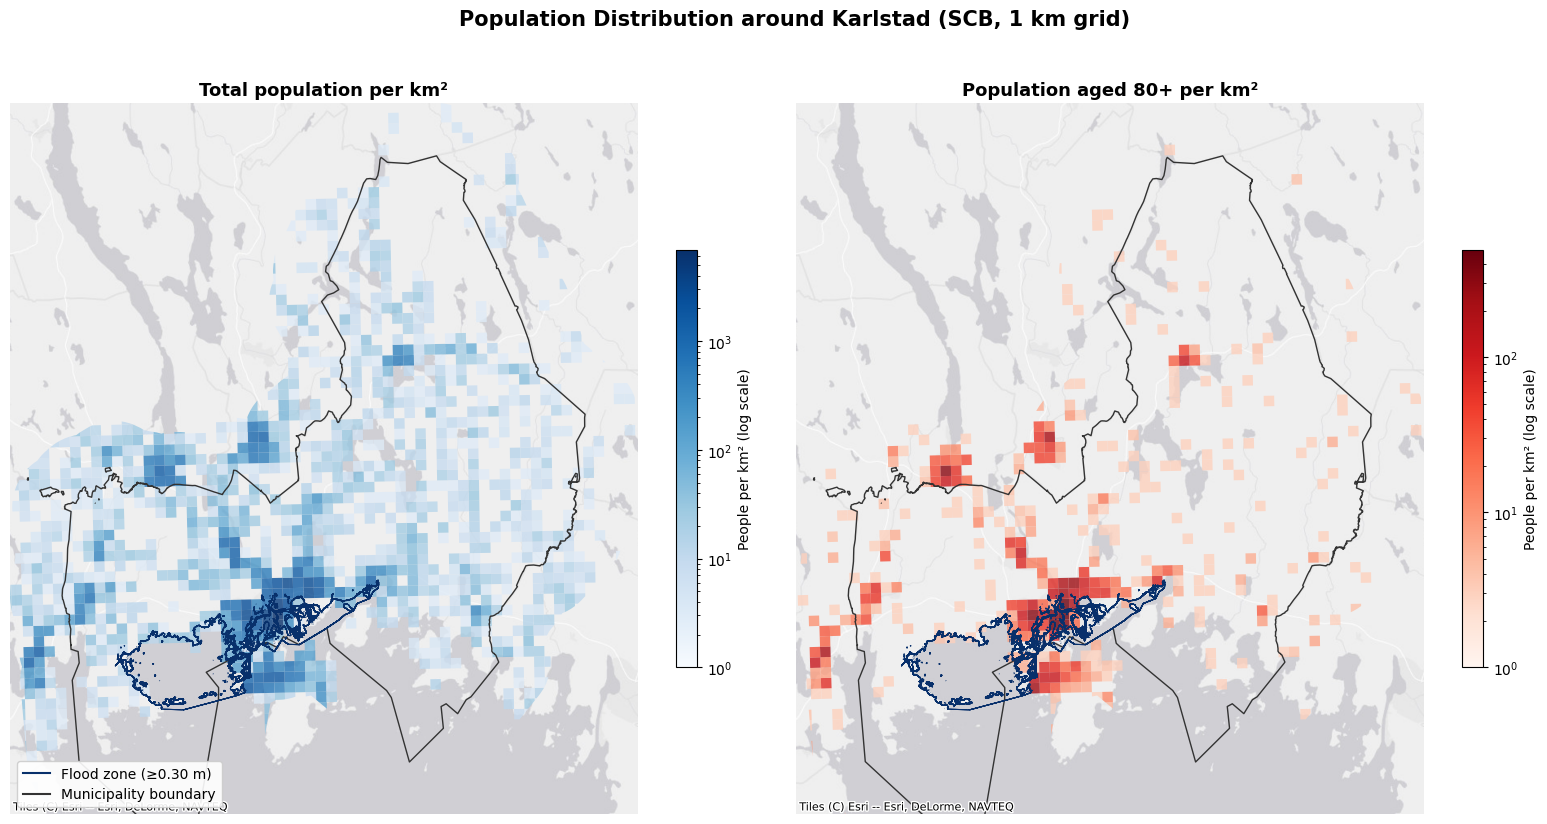

In [ ]:
# 4. MAP: where people live, and where the 80+ population lives
from matplotlib.colors import LogNorm

fig8, axes = plt.subplots(1, 2, figsize=(16, 9))
xmin, ymin, xmax, ymax = pop_gdf.total_bounds  # same extent in both panels

map_layers = [
    (pop_col,          "Blues", "Total population per km²"),
    ("elderly_80plus", "Reds",  "Population aged 80+ per km²"),
]

for ax, (col, cmap, title) in zip(axes, map_layers):
    cells = pop_gdf[pop_gdf[col] > 0]  # empty cells are left transparent
    # Log colour scale: a few city-centre cells are far denser than the rest
    cells.plot(ax=ax, column=col, cmap=cmap, alpha=0.8, linewidth=0,
               norm=LogNorm(vmin=1, vmax=cells[col].max()),
               legend=True, legend_kwds={"shrink": 0.5, "label": "People per km² (log scale)"})
    gdf_proj.boundary.plot(ax=ax, color="#333333", linewidth=1)
    flood_zone_web.boundary.plot(ax=ax, color="#08306b", linewidth=0.8)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas, zorder=0)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()

axes[0].legend(handles=[Line2D([0], [0], color="#08306b", lw=1.5, label="Flood zone (≥0.30 m)"),
                        Line2D([0], [0], color="#333333", lw=1.5, label="Municipality boundary")],
               loc="lower left", frameon=True, framealpha=0.9)

fig8.suptitle("Population Distribution around Karlstad (SCB, 1 km grid)",
              fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()
plt.close(fig8)

    Facility  Population access (10min, Normal)  Population access (10min, Flood)  Population losing access  Loss (%)  Vulnerable group  Group losing access  Group loss (%)
    Hospital                              54810                              8398                     46412      84.7          Aged 80+                 3078            88.3
Fire Station                              64777                             26074                     38703      59.7          Aged 80+                 2229            54.6
      School                              67576                             60682                      6894      10.2 School age (5-19)                  536             5.0


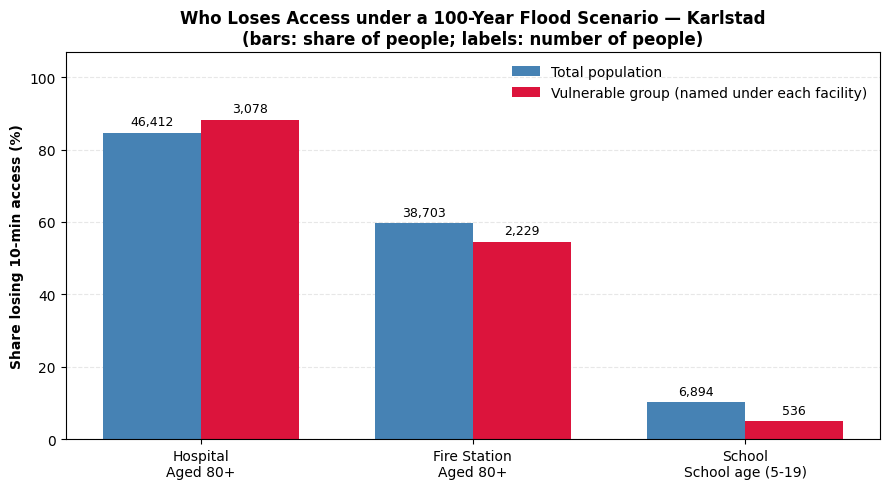

In [ ]:
# 5. Use grid-cell centroids to represent population locations
pop_centroids = pop_gdf.copy()
pop_centroids["geometry"] = pop_centroids.geometry.centroid

# 6. Calculate population within a given travel-time isochrone
def population_within(iso, t_min, pop_centroids, col):
    if iso is None:
        return 0
    sub = iso[iso["t_min"] == t_min]
    if sub.empty:
        return 0

    reach_zone = sub.geometry.union_all()
    inside = pop_centroids[pop_centroids.within(reach_zone)]
    return inside[col].sum()

# 7. Compare access under normal and flood conditions
# Each facility is paired with the vulnerable group that depends on it most
T = 10
results = []

for label, iso_n, iso_f, group_col, group_name in [
    ("Hospital",     iso_h_norm, iso_h_flood, "elderly_80plus", "Aged 80+"),
    ("Fire Station", iso_f_norm, iso_f_flood, "elderly_80plus", "Aged 80+"),
    ("School",       iso_s_norm, iso_s_flood, "school_age",     "School age (5-19)"),
]:
    pop_norm = population_within(iso_n, T, pop_centroids, pop_col)
    pop_flood = population_within(iso_f, T, pop_centroids, pop_col)

    grp_norm = population_within(iso_n, T, pop_centroids, group_col)
    grp_flood = population_within(iso_f, T, pop_centroids, group_col)

    results.append({
        "Facility": label,
        f"Population access ({T}min, Normal)": pop_norm,
        f"Population access ({T}min, Flood)": pop_flood,
        "Population losing access": pop_norm - pop_flood,
        "Loss (%)": (pop_norm - pop_flood) / pop_norm * 100 if pop_norm > 0 else 0,
        "Vulnerable group": group_name,
        "Group losing access": grp_norm - grp_flood,
        "Group loss (%)": (grp_norm - grp_flood) / grp_norm * 100 if grp_norm > 0 else 0,
    })

pop_exposure = pd.DataFrame(results)
print(pop_exposure.round(1).to_string(index=False))

# 8. PLOTTING TIME
# Both bars use the same scale: share of people with normal access who lose it
fig9, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pop_exposure))
bar_w = 0.36

bars_total = ax.bar(x - bar_w/2, pop_exposure["Loss (%)"], bar_w,
                    color="steelblue", label="Total population")
bars_group = ax.bar(x + bar_w/2, pop_exposure["Group loss (%)"], bar_w,
                    color="crimson", label="Vulnerable group (named under each facility)")

# Number of people on top of each bar
ax.bar_label(bars_total, labels=[f"{v:,.0f}" for v in pop_exposure["Population losing access"]],
             padding=3, fontsize=9)
ax.bar_label(bars_group, labels=[f"{v:,.0f}" for v in pop_exposure["Group losing access"]],
             padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{f}\n{g}" for f, g in
                    zip(pop_exposure["Facility"], pop_exposure["Vulnerable group"])])
ax.set_ylabel(f"Share losing {T}-min access (%)", fontweight="bold")
ax.set_ylim(0, max(pop_exposure["Loss (%)"].max(), pop_exposure["Group loss (%)"].max()) * 1.2 + 1)
ax.set_title(
    "Who Loses Access under a 100-Year Flood Scenario — Karlstad\n"
    "(bars: share of people; labels: number of people)",
    fontweight="bold")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
plt.close(fig9)

## **Land Cover Exposure Analysis**

The land cover dataset (NMD2018) comes from Sweden's National Land Cover Database, produced by
Naturvårdsverket (https://geodatakatalogen.naturvardsverket.se/geonetwork/srv/swe/catalog.search),
derived primarily from satellite imagery and laser scanning.

The file downloads automatically as
***"Karlstad_nmd2018.tif"*** together with the other datasets (see Environment Set Up).

The flood mask of the 100-year scenario is overlaid on the land cover raster to calculate the flooded area per land cover class.

In [ ]:
# 1. Get the flood mask for the reference 100yr scenario
# (reuses get_flood_mask() defined earlier -- same threshold as the rest of the notebook)
flood_mask, flood_depth, flood_transform, flood_crs, _ = get_flood_mask("Karlstad_100_djup.tif")

# 2. Open the Swedish Land Cover raster and align it to the flood raster's grid
# (the flood raster covers only Karlstad at 2m x 2m resolution, the NMD raster
# covers the whole county at 10m x 10m resolution)
with rasterio.open("Karlstad_nmd2018.tif") as lc_src:
    left = flood_transform.c
    top = flood_transform.f
    right = left + flood_transform.a * flood_depth.shape[1]
    bottom = top + flood_transform.e * flood_depth.shape[0]

    window = from_bounds(left, bottom, right, top, transform=lc_src.transform)
    lc = lc_src.read(1, window=window)
    window_transform = lc_src.window_transform(window)

    # Nearest neighbour resampling because land cover is categorical data
    lc_resampled = np.empty(flood_depth.shape, dtype=lc.dtype)
    reproject(
        source=lc,
        destination=lc_resampled,
        src_transform=window_transform,
        src_crs=lc_src.crs,
        dst_transform=flood_transform,
        dst_crs=flood_crs,
        resampling=Resampling.nearest)
lc = lc_resampled

# 3. Keep only pixels located inside the flood extent, then count per class
flooded_landcover = lc[flood_mask]
classes, counts = np.unique(flooded_landcover, return_counts=True)

# 4. Calculate flooded area per class
pixel_area = abs(flood_transform.a * flood_transform.e)
summary = pd.DataFrame({
    "Class_ID": classes,
    "Flooded Pixels": counts,
    "Flooded Area (m2)": counts * pixel_area,
    "Flooded Area (ha)": counts * pixel_area / 10000,
    "Flooded Area (km2)": counts * pixel_area / 1e6,
}).sort_values("Flooded Area (ha)", ascending=False).reset_index(drop=True)

summary

,Class_ID,Flooded Pixels,Flooded Area (m2),Flooded Area (ha),Flooded Area (km2)
0,61,18330462,7.331754e+07,7331.754141,73.317541
1,2,1593409,6.373262e+06,637.326164,6.373262
2,42,383737,1.534858e+06,153.485784,1.534858
3,115,330935,1.323662e+06,132.366225,1.323662
4,3,176915,7.076184e+05,70.761844,0.707618
5,0,112843,4.513455e+05,45.134549,0.451345
6,125,103121,4.124598e+05,41.245977,0.412460
7,114,97218,3.888492e+05,38.884916,0.388849
8,116,75340,3.013423e+05,30.134230,0.301342
9,117,67288,2.691362e+05,26.913619,0.269136


In [ ]:
# 9. Creating a dictionary to describe NMD classes
class_dict = {
    2:   "Open wetland",
    3:   "Arable land",
    41:  "Other open land without vegetation",
    42:  "Other open land with vegetation",
    51:  "Developed land, building",
    52:  "Developed land, not building or road",
    53:  "Developed land, road",
    61:  "Lake / watercourse",
    62:  "Sea",
    111: "Pine/spruce-dominated coniferous forest, outside wetland",
    112: "Lodgepole pine forest, outside wetland",
    113: "Mixed coniferous/broadleaf forest, outside wetland",
    114: "Common broadleaf forest, outside wetland",
    115: "Common broadleaf forest with noble broadleaf, outside wetland",
    116: "Noble broadleaf forest, outside wetland",
    117: "Temporarily non-forest, outside wetland",
    118: "Forest >5m on unproductive land, outside wetland",
    121: "Pine/spruce-dominated coniferous forest, on wetland",
    122: "Lodgepole pine forest, on wetland",
    123: "Mixed coniferous/broadleaf forest, on wetland",
    124: "Common broadleaf forest, on wetland",
    125: "Common broadleaf forest (noble broadleaf, on wetland)",
    126: "Noble broadleaf forest, on wetland",
    127: "Temporarily non-forest, on wetland",
    128: "Forest >5m on unproductive land, on wetland",
    255: "Cloud / unclassified"}

# 10. Replace Class_ID with names
summary["Land Cover Class"] = summary["Class_ID"].map(class_dict)

# 11. Group the detailed NMD classes into broad land cover categories
group_names  = ["Water", "Wetland", "Arable land", "Open land", "Forest", "Built-up", "Roads"]
group_colors = ["#9ecae1", "#66c2a5", "#e6c229", "#c7e59a", "#1b7837", "#d73027", "#4d4d4d"]

group_of = {2: "Wetland", 3: "Arable land", 41: "Open land", 42: "Open land",
            51: "Built-up", 52: "Built-up", 53: "Roads", 61: "Water", 62: "Water"}
group_of.update({c: "Forest" for c in list(range(111, 119)) + list(range(121, 129))})

# Lookup table: NMD class id -> group number (0 = no data / unclassified)
lut = np.zeros(256, dtype=np.uint8)
for class_id, name in group_of.items():
    lut[class_id] = group_names.index(name) + 1
lc_group = lut[lc]

# 12. Flooded area per group, and share of each group that is flooded
# ("Total area" = area of that group inside the extent of the flood map)
n_groups = len(group_names)
flooded_px = np.bincount(lc_group[flood_mask], minlength=n_groups + 1)[1:]
total_px = np.bincount(lc_group.ravel(), minlength=n_groups + 1)[1:]

group_df = pd.DataFrame({
    "Land cover": group_names,
    "Flooded area (km2)": flooded_px * pixel_area / 1e6,
    "Total area (km2)": total_px * pixel_area / 1e6,
    "Color": group_colors})
group_df["Flooded share (%)"] = group_df["Flooded area (km2)"] / group_df["Total area (km2)"] * 100

# Most of the flood zone is water that is always there (lake and river)
flood_km2 = flood_mask.sum() * pixel_area / 1e6
water_km2 = group_df.loc[group_df["Land cover"] == "Water", "Flooded area (km2)"].iloc[0]
print(f"Flood zone (≥{DEPTH_THRESHOLD_M} m): {flood_km2:.1f} km²")
print(f"  of which permanent water (lake / river): {water_km2:.1f} km² ({water_km2 / flood_km2 * 100:.0f}%)")
land_km2 = group_df.loc[group_df["Land cover"] != "Water", "Flooded area (km2)"].sum()
print(f"  of which land: {land_km2:.1f} km²")
print(f"  no land cover data: {flood_km2 - water_km2 - land_km2:.1f} km²\n")
print(group_df.drop(columns="Color").round(2).to_string(index=False))

Flood zone (≥0.3 m): 86.3 km²
  of which permanent water (lake / river): 73.3 km² (85%)
  of which land: 12.5 km²
  no land cover data: 0.5 km²

 Land cover  Flooded area (km2)  Total area (km2)  Flooded share (%)
      Water               73.32            132.08              55.51
    Wetland                6.37             11.12              57.32
Arable land                0.71             20.79               3.40
  Open land                1.79             21.93               8.17
     Forest                3.31             95.20               3.47
   Built-up                0.13             11.48               1.10
      Roads                0.18              9.82               1.80


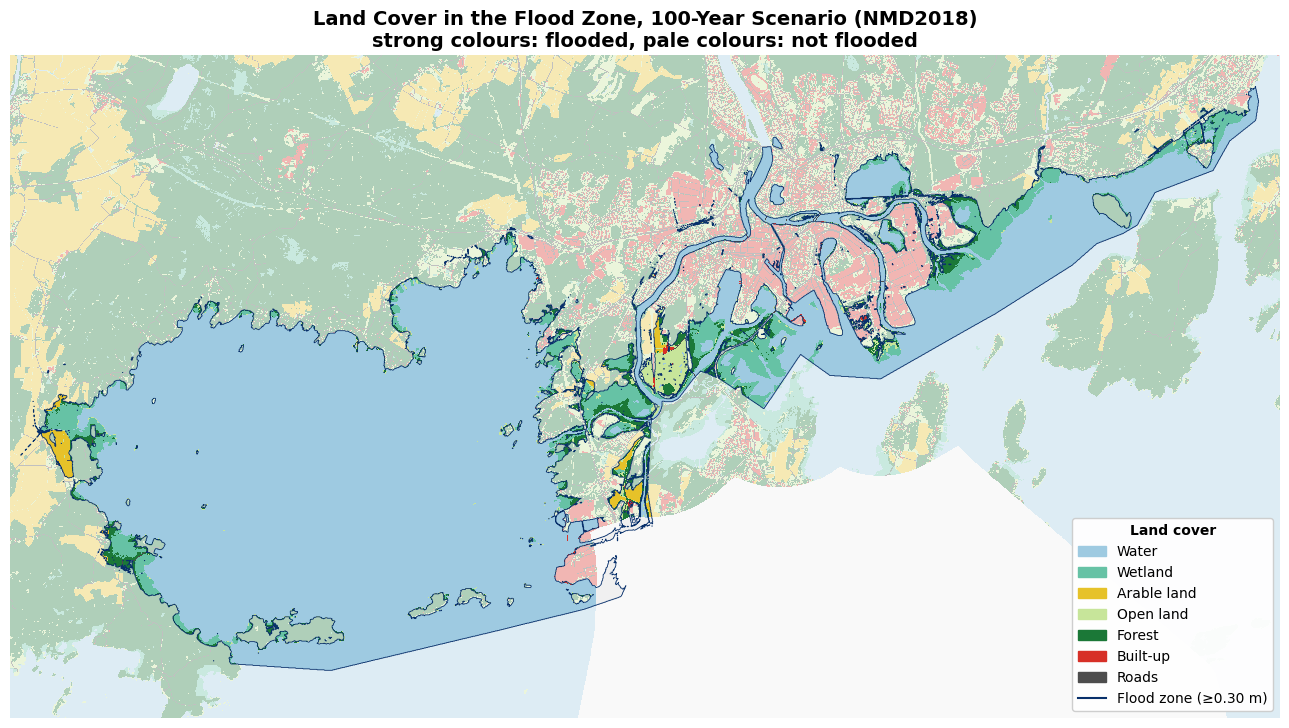

In [ ]:
# 13. MAP: land cover inside and around the flood zone
from matplotlib.colors import ListedColormap

# Back to the 10 m resolution of the land cover data (much faster to draw)
step = 5
lc_small = lc_group[::step, ::step]
mask_small = flood_mask[::step, ::step]

# Zoom to the flood zone, with a small margin
rows = np.where(mask_small.any(axis=1))[0]
cols = np.where(mask_small.any(axis=0))[0]
pad = 100  # cells (= 1 km)
r0, r1 = max(rows.min() - pad, 0), min(rows.max() + pad, lc_small.shape[0])
c0, c1 = max(cols.min() - pad, 0), min(cols.max() + pad, lc_small.shape[1])
lc_zoom = lc_small[r0:r1, c0:c1]
mask_zoom = mask_small[r0:r1, c0:c1]

# Map coordinates of the zoomed window (same CRS as the flood raster)
cell = flood_transform.a * step
x_min = flood_transform.c + c0 * cell
x_max = flood_transform.c + c1 * cell
y_max = flood_transform.f - r0 * cell
y_min = flood_transform.f - r1 * cell
extent = [x_min, x_max, y_min, y_max]

cmap = ListedColormap(["#f0f0f0"] + group_colors)  # first colour = no data
style = dict(cmap=cmap, vmin=0, vmax=n_groups, extent=extent, interpolation="nearest")

fig10, ax = plt.subplots(figsize=(13, 9))
# All land cover in pale colours, flooded pixels in full colour on top
ax.imshow(lc_zoom, alpha=0.35, **style)
ax.imshow(np.ma.masked_where(~mask_zoom, lc_zoom), **style)
# Outline of the flood zone
ax.contour(mask_zoom, levels=[0.5], colors="#08306b", linewidths=0.6,
           extent=extent, origin="upper")

handles = [mpatches.Patch(color=c, label=n) for n, c in zip(group_names, group_colors)]
handles.append(Line2D([0], [0], color="#08306b", lw=1.5, label="Flood zone (≥0.30 m)"))
ax.legend(handles=handles, loc="lower right", frameon=True, framealpha=0.95,
          title="Land cover", title_fontproperties={"weight": "bold"})

ax.set_title("Land Cover in the Flood Zone, 100-Year Scenario (NMD2018)\n"
             "strong colours: flooded, pale colours: not flooded",
             fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.close(fig10)

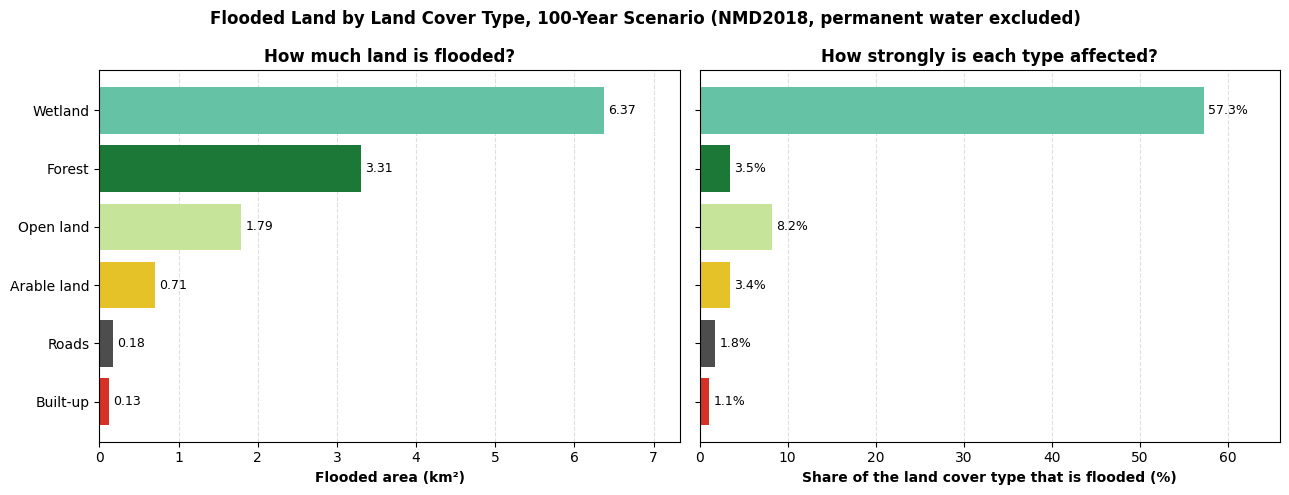

In [ ]:
# 14. PLOTTING TIME :)
# Permanent water is left out, so the chart shows the land that gets flooded
land_df = group_df[group_df["Land cover"] != "Water"].sort_values("Flooded area (km2)")

fig11, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

bars_a = ax_a.barh(land_df["Land cover"], land_df["Flooded area (km2)"], color=land_df["Color"])
ax_a.bar_label(bars_a, fmt="%.2f", padding=3, fontsize=9)
ax_a.set_xlabel("Flooded area (km²)", fontweight="bold")
ax_a.set_title("How much land is flooded?", fontweight="bold")

bars_b = ax_b.barh(land_df["Land cover"], land_df["Flooded share (%)"], color=land_df["Color"])
ax_b.bar_label(bars_b, fmt="%.1f%%", padding=3, fontsize=9)
ax_b.set_xlabel("Share of the land cover type that is flooded (%)", fontweight="bold")
ax_b.set_title("How strongly is each type affected?", fontweight="bold")

for ax in (ax_a, ax_b):
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.margins(x=0.15)

fig11.suptitle("Flooded Land by Land Cover Type, 100-Year Scenario (NMD2018, permanent water excluded)",
               fontweight="bold")
fig11.tight_layout()
plt.show()
plt.close(fig11)

# **B: Supplemental Analysis**

This section is not covered live in the workshop due to time constraints — it is provided
for self-study after the session. It extends the Section A methodology (real flood polygon,
depth threshold, exposure analysis) across three flood scenarios (50yr/100yr/200yr) for
comparative risk analysis.

If you already ran Section A in this session, you can continue directly — this section reuses
the same functions, datasets, and variables. If you are starting from a fresh runtime and want
to run Section B on its own, run the **Section B standalone setup** cell below first; it
downloads the required datasets and re-creates everything this section needs, without
requiring Section A.

## **Environment Set Up [B]** *(optional)*

Run this cell **only** if you start Section B from a fresh runtime without running Section A. Otherwise skip it and continue with the next section.

In [ ]:
# Section B standalone setup
# Run this cell first if you are starting a fresh runtime and want to run
# Section B on its own, without running Section A. If you already ran
# Section A in this session, this cell is safe to skip (or re-run --
# it just re-creates the same objects, no harm done).

!pip install -q geopandas==1.0.1 rasterio==1.4.3 shapely==2.1.1 pyproj==3.7.0

import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.features import shapes
from rasterio.warp import reproject, Resampling
from rasterio.windows import from_bounds
from shapely.geometry import shape
from shapely.ops import unary_union
import matplotlib.pyplot as plt

# 1. Download required datasets (same as Environment Set Up)
BASE_URL = "https://raw.githubusercontent.com/sesac-sweden/riscon26-workshop/main"
FILES = [
    "Karlstad_100_djup.tif",
    "Karlstad_200_djup.tif",
    "Karlstad_50_djup.tif",
    "Karlstad_nmd2018.tif",
    "karlstad_osm.gpkg",
    "karlstad_pois.gpkg",
]
for f in FILES:
    !wget -q -N "{BASE_URL}/{f}"

# 2. Shared flood-detection functions (same as Section A)
DEPTH_THRESHOLD_M = 0.30  # Pregnolato et al. (2017): max safe depth for driving/steering

def get_flood_mask(raster_path, depth_threshold_m=DEPTH_THRESHOLD_M):
    with rasterio.open(raster_path) as src:
        depth = src.read(1)
        transform = src.transform
        crs = src.crs
        nodata = src.nodata
    valid = (depth != nodata) if nodata is not None else np.isfinite(depth)
    mask = (depth >= depth_threshold_m) & valid
    return mask, depth, transform, crs, valid

def get_flood_polygon(raster_path, depth_threshold_m=DEPTH_THRESHOLD_M):
    mask, depth, transform, crs, valid = get_flood_mask(raster_path, depth_threshold_m)
    polygons = [
        shape(geom)
        for geom, val in shapes(mask.astype(np.uint8), mask=mask, transform=transform)
        if val == 1
    ]
    flood_geom = unary_union(polygons) if polygons else None
    gdf = gpd.GeoDataFrame(geometry=[flood_geom] if flood_geom else [], crs=crs)
    return gdf, mask, depth, transform, crs

# 3. Load buildings and roads (same clip logic as Section A)
gdf_boundary = gpd.read_file("karlstad_osm.gpkg", layer="boundary")
gdf_proj = gdf_boundary.to_crs(epsg=3857)
osm_proj = gpd.read_file("karlstad_osm.gpkg", layer="features").to_crs(epsg=3857)

def _clip(layer):
    return gpd.clip(layer, gdf_proj)

def _remove_points(layer):
    return layer[layer.geometry.type.isin(["Polygon", "MultiPolygon", "LineString", "MultiLineString"])]

buildings = _remove_points(_clip(osm_proj[osm_proj["building"].notna()]))
roads = _remove_points(_clip(osm_proj[osm_proj["highway"].notna()]))

# 4. Load critical infrastructure
hospitals_all = gpd.read_file("karlstad_pois.gpkg", layer="hospitals")
fire_stations_all = gpd.read_file("karlstad_pois.gpkg", layer="fire_stations")
schools_all = gpd.read_file("karlstad_pois.gpkg", layer="schools")

# 5. Land cover class dictionary (NMD2018 basskikt codes)
class_dict = {
    2:   "Open wetland",
    3:   "Arable land",
    41:  "Other open land without vegetation",
    42:  "Other open land with vegetation",
    51:  "Developed land, building",
    52:  "Developed land, not building or road",
    53:  "Developed land, road",
    61:  "Lake / watercourse",
    62:  "Sea",
    111: "Pine/spruce-dominated coniferous forest, outside wetland",
    112: "Lodgepole pine forest, outside wetland",
    113: "Mixed coniferous/broadleaf forest, outside wetland",
    114: "Common broadleaf forest, outside wetland",
    115: "Common broadleaf forest with noble broadleaf, outside wetland",
    116: "Noble broadleaf forest, outside wetland",
    117: "Temporarily non-forest, outside wetland",
    118: "Forest >5m on unproductive land, outside wetland",
    121: "Pine/spruce-dominated coniferous forest, on wetland",
    122: "Lodgepole pine forest, on wetland",
    123: "Mixed coniferous/broadleaf forest, on wetland",
    124: "Common broadleaf forest, on wetland",
    125: "Common broadleaf forest (noble broadleaf, on wetland)",
    126: "Noble broadleaf forest, on wetland",
    127: "Temporarily non-forest, on wetland",
    128: "Forest >5m on unproductive land, on wetland",
    255: "Cloud / unclassified"}

print("Section B setup complete -- ready to run independently.")

Section B setup complete -- ready to run independently.


## **Comparison of Extreme Flood Scenarios**

The flood zone is detected for the 50-, 100- and 200-year scenarios with the same functions and depth threshold as in Section A, and the flooded buildings and roads are compared across scenarios.

In [ ]:
# 1. Dictionary of flood scenarios
flood_scenarios = {"50yr": "Karlstad_50_djup.tif",
                    "100yr": "Karlstad_100_djup.tif",
                    "200yr": "Karlstad_200_djup.tif"}

# 2. Reproject buildings and roads ONCE (same CRS for all three flood rasters),
# instead of re-projecting inside the loop for every scenario.
_reference_crs = get_flood_mask("Karlstad_100_djup.tif")[3]
buildings_proj = buildings.to_crs(_reference_crs)
roads_proj = roads.to_crs(_reference_crs)

# Build a spatial index once -- makes the intersects() check much faster
# than testing every building/road one by one against the flood polygon.
buildings_sindex = buildings_proj.sindex
roads_sindex = roads_proj.sindex

# 3. Analyse one flood scenario, reusing get_flood_polygon() defined in Section A
def analyse_scenario(raster_path, buildings_proj, roads_proj, buildings_sindex, roads_sindex):
    zone_gdf, mask, depth, transform, crs = get_flood_polygon(raster_path)
    pixel_area = abs(transform.a * transform.e)

    results = {}
    results["Flooded Area (km²)"] = mask.sum() * pixel_area / 1e6

    valid_depth = depth[mask]
    results["Mean Depth (m)"] = np.mean(valid_depth) if valid_depth.size else 0
    results["Maximum Depth (m)"] = np.max(valid_depth) if valid_depth.size else 0

    if not zone_gdf.empty:
        zone_geom = zone_gdf.geometry.iloc[0]

        # Use the spatial index to shortlist candidates, then confirm with a
        # precise intersects() check -- much faster than testing every feature.
        b_candidates = buildings_proj.iloc[buildings_sindex.query(zone_geom, predicate="intersects")]
        r_candidates = roads_proj.iloc[roads_sindex.query(zone_geom, predicate="intersects")]

        results["Buildings"] = len(b_candidates)
        results["Roads"] = len(r_candidates)
    else:
        results["Buildings"] = 0
        results["Roads"] = 0

    return results

# 4. Run the analysis for all scenarios
summary = []
for scenario, raster in flood_scenarios.items():
    print(f"Processing {scenario} scenario...")
    stats = analyse_scenario(
        raster_path=raster,
        buildings_proj=buildings_proj,
        roads_proj=roads_proj,
        buildings_sindex=buildings_sindex,
        roads_sindex=roads_sindex)
    stats["Scenario"] = scenario
    summary.append(stats)

summary = pd.DataFrame(summary)
summary

Processing 50yr scenario...
Processing 100yr scenario...
Processing 200yr scenario...


,Flooded Area (km²),Mean Depth (m),Maximum Depth (m),Buildings,Roads,Scenario
0,81.761185,1.010764,1.05,58,312,50yr
1,86.251634,1.479411,1.57,217,572,100yr
2,87.526183,1.670979,1.78,349,725,200yr


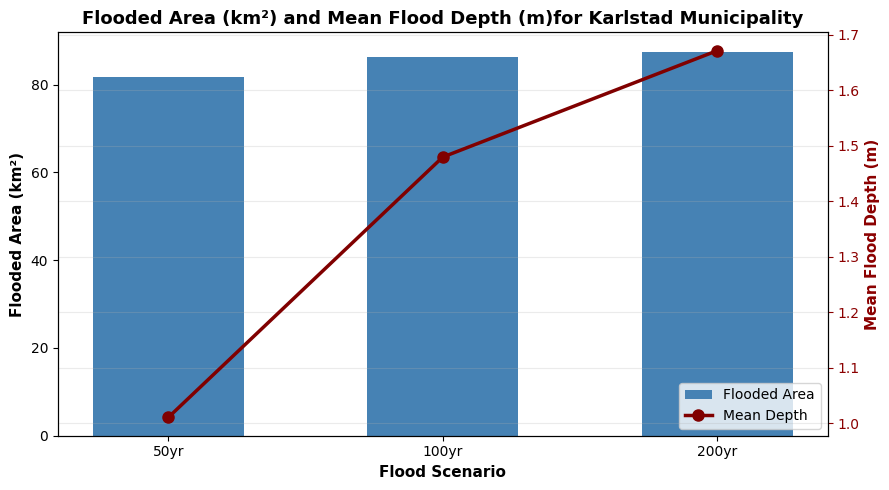

In [ ]:
#4. PLOTTING TIME
fig10, ax1 = plt.subplots(figsize=(9,5))
# Left axis - Flooded Area (km²)
bars = ax1.bar(
    summary["Scenario"],
    summary["Flooded Area (km²)"],
    width=0.55,
    color="steelblue",
    label="Flooded Area")

ax1.set_ylabel(
    "Flooded Area (km²)",
    fontsize=11,
    fontweight="bold")

ax1.set_xlabel(
    "Flood Scenario",
    fontsize=11,
    fontweight="bold")

# Right axis - Mean Flood Depth (red)
ax2 = ax1.twinx()
line = ax2.plot(
    summary["Scenario"],
    summary["Mean Depth (m)"],
    color="maroon",
    marker="o",
    markersize=8,
    linewidth=2.5,
    label="Mean Depth")

ax2.set_ylabel(
    "Mean Flood Depth (m)",
    color = "darkred",
    fontsize=11,
    fontweight="bold")
ax2.tick_params(axis="y", colors="darkred")

plt.title( #title
    "Flooded Area (km²) and Mean Flood Depth (m)for Karlstad Municipality",
    fontsize=13,
    fontweight="bold")

handles1, labels1 = ax1.get_legend_handles_labels() #customized legend
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower right")
plt.grid(alpha =0.25)
plt.tight_layout()
plt.show()
plt.close(fig10)

## **Exposure Analysis across Extreme Flood Scenarios**

Exposure of buildings, roads and critical infrastructure is calculated for every scenario, to show how impacts grow with flood severity.

In [ ]:
# 3. Exposure analysis for every flood scenario (buildings, roads & critical infrastructure)
# Reproject all assets ONCE (same CRS across all three flood rasters),
# instead of re-projecting inside the loop for every scenario.
_reference_crs = get_flood_mask("Karlstad_100_djup.tif")[3]
buildings_s = buildings.to_crs(_reference_crs)
roads_s = roads.to_crs(_reference_crs)
hospitals_s = hospitals_all.to_crs(_reference_crs)
firestations_s = fire_stations_all.to_crs(_reference_crs)
schools_s = schools_all.to_crs(_reference_crs)

# Spatial indexes for the larger layers (buildings, roads) -- makes the
# intersects() check much faster than testing every feature one by one.
buildings_sindex = buildings_s.sindex
roads_sindex = roads_s.sindex

exposure_records = []

for scenario, raster_path in flood_scenarios.items():
    print(f"Analysing exposure -- {scenario} scenario...")

    flood_zone_s, flood_mask_s, depth_s, transform_s, crs_s = get_flood_polygon(raster_path)
    pixel_area = abs(transform_s.a * transform_s.e)
    zone_geom = flood_zone_s.geometry.iloc[0]

    # Buildings & roads: use the spatial index to shortlist candidates first
    exp_buildings = buildings_s.iloc[buildings_sindex.query(zone_geom, predicate="intersects")]
    exp_roads = roads_s.iloc[roads_sindex.query(zone_geom, predicate="intersects")]

    # Critical infrastructure: tiny layers (1-53 features), a direct
    # intersects() check is already fast enough, no index needed
    exp_hospitals = hospitals_s[hospitals_s.intersects(zone_geom)]
    exp_firestations = firestations_s[firestations_s.intersects(zone_geom)]
    exp_schools = schools_s[schools_s.intersects(zone_geom)]

    valid_depth = depth_s[flood_mask_s]

    exposure_records.append({
        "Scenario": scenario,
        "Return Period (yr)": int(scenario.replace("yr", "")),
        "Flooded Area (km²)": flood_mask_s.sum() * pixel_area / 1e6,
        "Mean Depth (m)": np.mean(valid_depth),
        "Max Depth (m)": np.max(valid_depth),
        "Exposed Buildings": len(exp_buildings),
        "Exposed Buildings (%)": len(exp_buildings) / len(buildings_s) * 100,
        "Exposed Roads": len(exp_roads),
        "Exposed Roads (%)": len(exp_roads) / len(roads_s) * 100,
        "Exposed Hospitals": len(exp_hospitals),
        "Exposed Fire Stations": len(exp_firestations),
        "Exposed Schools": len(exp_schools)})

exposure_summary = pd.DataFrame(exposure_records).sort_values("Return Period (yr)").reset_index(drop=True)
exposure_summary

Analysing exposure -- 50yr scenario...
Analysing exposure -- 100yr scenario...
Analysing exposure -- 200yr scenario...


,Scenario,Return Period (yr),Flooded Area (km²),Mean Depth (m),Max Depth (m),Exposed Buildings,Exposed Buildings (%),Exposed Roads,Exposed Roads (%),Exposed Hospitals,Exposed Fire Stations,Exposed Schools
0,50yr,50,81.761185,1.010764,1.05,58,0.200477,312,1.554094,1,0,1
1,100yr,100,86.251634,1.479411,1.57,217,0.750060,572,2.849173,1,0,2
2,200yr,200,87.526183,1.670979,1.78,349,1.206318,725,3.611277,1,0,3


In [ ]:
# 3. PLOTTING TIME - Exposed share of buildings & roads (left axis),
# with exposed critical infrastructure counts on a separate right axis
fig11, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(exposure_summary))
bar_w = 0.3

# Left axis - Buildings & Roads, exposed share (%)
ax1.bar(x - bar_w/2, exposure_summary["Exposed Buildings (%)"], bar_w,
        color="steelblue", label="Buildings", edgecolor="white")
ax1.bar(x + bar_w/2, exposure_summary["Exposed Roads (%)"], bar_w,
        color="darkorange", label="Roads", edgecolor="white")

ax1.set_xticks(x)
ax1.set_xticklabels(exposure_summary["Scenario"], fontsize=11)
ax1.set_ylabel("Exposed share of total stock (%)", fontweight="bold")
ax1.set_xlabel("Flood Scenario (Return Period)", fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Right axis - Exposed critical infrastructure counts (Hospitals, Fire Stations, Schools)
ax2 = ax1.twinx()
ax2.plot(x, exposure_summary["Exposed Hospitals"], marker="o", linewidth=2,
         color="crimson", label="Hospitals")
ax2.plot(x, exposure_summary["Exposed Fire Stations"], marker="s", linewidth=2,
         color="seagreen", label="Fire Stations")
ax2.plot(x, exposure_summary["Exposed Schools"], marker="^", linewidth=2,
         color="purple", label="Schools")

ax2.set_ylabel("Exposed critical infrastructure (count)", fontweight="bold")
ax2.spines["top"].set_visible(False)

ax1.set_title("Exposure of Buildings, Roads & Critical Infrastructure\nAcross Flood Return Periods — Karlstad",
              fontsize=13, fontweight="bold")

# Combined legend from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, loc="upper left")

plt.tight_layout()
plt.show()
plt.close(fig11)

NameError: name 'plt' is not defined

## **Severity vs Likelihood: Annual Exceedance Probability (AEP)**

**Note:** the return periods used here
(100yr/200yr) are MSB scenarios based on river flows adjusted to end-of-century
climate conditions — they are not present-day flood probabilities.  **The chart
below illustrates the mathematical relationship between severity (return period)
and likelihood (AEP = 1/T); it is a teaching simplification, not a current-day
risk estimate.** Under today's climate, the true annual probability of a flood
this size is lower than the AEP values shown.

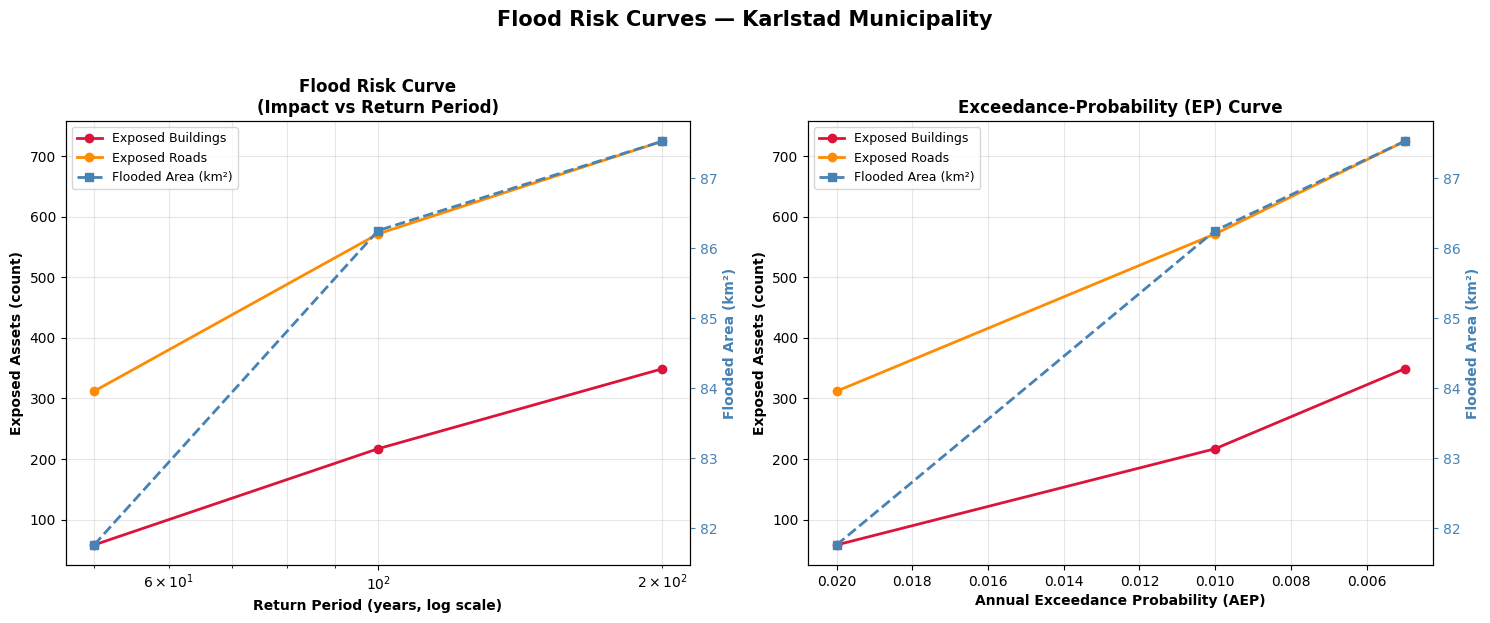

In [ ]:
# 4. Annual Exceedance Probability (AEP = 1/T) for each scenario
exposure_summary["AEP"] = 1 / exposure_summary["Return Period (yr)"]

#5. PLOTTING TIME
fig12, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left panel: Impact vs Return Period ----
ax_left = axes[0]
ax_left2 = ax_left.twinx()

ax_left.plot(exposure_summary["Return Period (yr)"], exposure_summary["Exposed Buildings"],
             marker="o", linewidth=2, color="crimson", label="Exposed Buildings")
ax_left.plot(exposure_summary["Return Period (yr)"], exposure_summary["Exposed Roads"],
             marker="o", linewidth=2, color="darkorange", label="Exposed Roads")
ax_left2.plot(exposure_summary["Return Period (yr)"], exposure_summary["Flooded Area (km²)"],
              marker="s", linewidth=2, linestyle="--", color="steelblue", label="Flooded Area (km²)")

ax_left.set_xscale("log")
ax_left.set_xlabel("Return Period (years, log scale)", fontweight="bold")
ax_left.set_ylabel("Exposed Assets (count)", fontweight="bold")
ax_left2.set_ylabel("Flooded Area (km²)", color="steelblue", fontweight="bold")
ax_left2.tick_params(axis="y", colors="steelblue")
ax_left.set_title("Flood Risk Curve\n(Impact vs Return Period)", fontweight="bold")
ax_left.grid(alpha=0.3, which="both")

h1, l1 = ax_left.get_legend_handles_labels()
h2, l2 = ax_left2.get_legend_handles_labels()
ax_left.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper left")

# ---- Right panel: Impact vs Annual Exceedance Probability ----
ax_right = axes[1]
ax_right2 = ax_right.twinx()

ax_right.plot(exposure_summary["AEP"], exposure_summary["Exposed Buildings"],
              marker="o", linewidth=2, color="crimson", label="Exposed Buildings")
ax_right.plot(exposure_summary["AEP"], exposure_summary["Exposed Roads"],
              marker="o", linewidth=2, color="darkorange", label="Exposed Roads")
ax_right2.plot(exposure_summary["AEP"], exposure_summary["Flooded Area (km²)"],
               marker="s", linewidth=2, linestyle="--", color="steelblue", label="Flooded Area (km²)")

ax_right.invert_xaxis()  # probability decreases towards rarer / more severe events
ax_right.set_xlabel("Annual Exceedance Probability (AEP)", fontweight="bold")
ax_right.set_ylabel("Exposed Assets (count)", fontweight="bold")
ax_right2.set_ylabel("Flooded Area (km²)", color="steelblue", fontweight="bold")
ax_right2.tick_params(axis="y", colors="steelblue")
ax_right.set_title("Exceedance-Probability (EP) Curve", fontweight="bold")
ax_right.grid(alpha=0.3, which="both")

h1, l1 = ax_right.get_legend_handles_labels()
h2, l2 = ax_right2.get_legend_handles_labels()
ax_right.legend(h1 + h2, l1 + l2, fontsize=9, loc="upper left")

fig12.suptitle("Flood Risk Curves — Karlstad Municipality", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()
plt.close(fig12)